# AI-Driven Decision Intelligence Platform

## Step 3: Data Understanding, Data Quality & Cleaning

### Objective

The objective of this notebook is to understand the structure,
quality, and relationships within the Olist Brazilian E-Commerce
dataset before performing exploratory analysis and machine learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [2]:
customers = pd.read_csv("../data/raw/olist_customers_dataset.csv")
orders = pd.read_csv("../data/raw/olist_orders_dataset.csv")
order_items = pd.read_csv("../data/raw/olist_order_items_dataset.csv")
payments = pd.read_csv("../data/raw/olist_order_payments_dataset.csv")
reviews = pd.read_csv("../data/raw/olist_order_reviews_dataset.csv")
products = pd.read_csv("../data/raw/olist_products_dataset.csv")
sellers = pd.read_csv("../data/raw/olist_sellers_dataset.csv")
geolocation = pd.read_csv("../data/raw/olist_geolocation_dataset.csv")
category_translation = pd.read_csv(
    "../data/raw/product_category_name_translation.csv"
)

In [3]:
"../data/raw/"

'../data/raw/'

In [4]:
datasets = {
    "customers": customers,
    "orders": orders,
    "order_items": order_items,
    "payments": payments,
    "reviews": reviews,
    "products": products,
    "sellers": sellers,
    "geolocation": geolocation,
    "category_translation": category_translation
}

for name, df in datasets.items():
    print(f"{name}: {df.shape}")

customers: (99441, 5)
orders: (99441, 8)
order_items: (112650, 7)
payments: (103886, 5)
reviews: (99224, 7)
products: (32951, 9)
sellers: (3095, 4)
geolocation: (1000163, 5)
category_translation: (71, 2)


In [5]:
print("CUSTOMERS")
display(customers.head())

print("ORDERS")
display(orders.head())

print("ORDER ITEMS")
display(order_items.head())

print("PRODUCTS")
display(products.head())

print("REVIEWS")
display(reviews.head())

CUSTOMERS


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


ORDERS


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


ORDER ITEMS


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


PRODUCTS


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


REVIEWS


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [6]:
print("PAYMENTS")
display(payments.head())

print("SELLERS")
display(sellers.head())

print("GEOLOCATION")
display(geolocation.head())

print("CATEGORY TRANSLATION")
display(category_translation.head())

PAYMENTS


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


SELLERS


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


GEOLOCATION


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


CATEGORY TRANSLATION


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [7]:
for name, df in datasets.items():
    print(f"\n{'=' * 60}")
    print(name.upper())
    print("=" * 60)
    print(df.columns.tolist())


CUSTOMERS
['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

ORDERS
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

ORDER_ITEMS
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

PAYMENTS
['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']

REVIEWS
['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']

PRODUCTS
['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']

SELLERS
['seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state']

GEOLOCATION
['geolocation_zi

In [8]:
for name, df in datasets.items():
    print(f"\n{'=' * 60}")
    print(name.upper())
    print("=" * 60)
    print(df.dtypes)


CUSTOMERS
customer_id                   str
customer_unique_id            str
customer_zip_code_prefix    int64
customer_city                 str
customer_state                str
dtype: object

ORDERS
order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str
dtype: object

ORDER_ITEMS
order_id                   str
order_item_id            int64
product_id                 str
seller_id                  str
shipping_limit_date        str
price                  float64
freight_value          float64
dtype: object

PAYMENTS
order_id                    str
payment_sequential        int64
payment_type                str
payment_installments      int64
payment_value           float64
dtype: object

REVIEWS
review_id                    str
order_id         

In [9]:
for name, df in datasets.items():
    print(f"\n{name.upper()}")
    print(df.info())


CUSTOMERS
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 3.8 MB
None

ORDERS
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approv

In [10]:
for name, df in datasets.items():
    print(f"\n{'=' * 60}")
    print(name.upper())
    print("=" * 60)
    
    missing = df.isnull().sum()
    missing = missing[missing > 0].sort_values(ascending=False)
    
    if len(missing) == 0:
        print("No missing values.")
    else:
        print(missing)


CUSTOMERS
No missing values.

ORDERS
order_delivered_customer_date    2965
order_delivered_carrier_date     1783
order_approved_at                 160
dtype: int64

ORDER_ITEMS
No missing values.

PAYMENTS
No missing values.

REVIEWS
review_comment_title      87656
review_comment_message    58247
dtype: int64

PRODUCTS
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

SELLERS
No missing values.

GEOLOCATION
No missing values.

CATEGORY_TRANSLATION
No missing values.


In [11]:
for name, df in datasets.items():
    print(f"\n{'=' * 60}")
    print(name.upper())
    print("=" * 60)
    
    missing_count = df.isnull().sum()
    missing_percentage = (missing_count / len(df)) * 100
    
    missing_summary = pd.DataFrame({
        "Missing_Count": missing_count,
        "Missing_Percentage": missing_percentage.round(2)
    })
    
    print(missing_summary[missing_summary["Missing_Count"] > 0])


CUSTOMERS
Empty DataFrame
Columns: [Missing_Count, Missing_Percentage]
Index: []

ORDERS
                               Missing_Count  Missing_Percentage
order_approved_at                        160                0.16
order_delivered_carrier_date            1783                1.79
order_delivered_customer_date           2965                2.98

ORDER_ITEMS
Empty DataFrame
Columns: [Missing_Count, Missing_Percentage]
Index: []

PAYMENTS
Empty DataFrame
Columns: [Missing_Count, Missing_Percentage]
Index: []

REVIEWS
                        Missing_Count  Missing_Percentage
review_comment_title            87656               88.34
review_comment_message          58247               58.70

PRODUCTS
                            Missing_Count  Missing_Percentage
product_category_name                 610                1.85
product_name_lenght                   610                1.85
product_description_lenght            610                1.85
product_photos_qty                    610   

In [12]:
missing_summary_all = {}

for name, df in datasets.items():
    missing_count = df.isnull().sum()
    missing_percentage = (missing_count / len(df)) * 100
    
    missing_summary_all[name] = pd.DataFrame({
        "Missing_Count": missing_count,
        "Missing_Percentage": missing_percentage.round(2)
    })

missing_summary_all

{'customers':                           Missing_Count  Missing_Percentage
 customer_id                           0                 0.0
 customer_unique_id                    0                 0.0
 customer_zip_code_prefix              0                 0.0
 customer_city                         0                 0.0
 customer_state                        0                 0.0,
 'orders':                                Missing_Count  Missing_Percentage
 order_id                                   0                0.00
 customer_id                                0                0.00
 order_status                               0                0.00
 order_purchase_timestamp                   0                0.00
 order_approved_at                        160                0.16
 order_delivered_carrier_date            1783                1.79
 order_delivered_customer_date           2965                2.98
 order_estimated_delivery_date              0                0.00,
 'order_items':

In [13]:
for name, df in datasets.items():
    duplicate_count = df.duplicated().sum()
    print(f"{name}: {duplicate_count} duplicate rows")

customers: 0 duplicate rows
orders: 0 duplicate rows
order_items: 0 duplicate rows
payments: 0 duplicate rows
reviews: 0 duplicate rows
products: 0 duplicate rows
sellers: 0 duplicate rows
geolocation: 261831 duplicate rows
category_translation: 0 duplicate rows


In [14]:
print("Customers - customer_id duplicates:",
      customers["customer_id"].duplicated().sum())

print("Orders - order_id duplicates:",
      orders["order_id"].duplicated().sum())

print("Products - product_id duplicates:",
      products["product_id"].duplicated().sum())

print("Sellers - seller_id duplicates:",
      sellers["seller_id"].duplicated().sum())

Customers - customer_id duplicates: 0
Orders - order_id duplicates: 0
Products - product_id duplicates: 0
Sellers - seller_id duplicates: 0


In [15]:
duplicate_summary = pd.DataFrame({
    "Dataset": list(datasets.keys()),
    "Duplicate_Rows": [
        df.duplicated().sum()
        for df in datasets.values()
    ]
})

duplicate_summary

,Dataset,Duplicate_Rows
0,customers,0
1,orders,0
2,order_items,0
3,payments,0
4,reviews,0
5,products,0
6,sellers,0
7,geolocation,261831
8,category_translation,0


In [16]:
print("Order Status:")
print(orders["order_status"].value_counts())

Order Status:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


In [17]:
print("Review Scores:")
print(reviews["review_score"].value_counts().sort_index())

Review Scores:
review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64


In [18]:
print("Number of unique product categories:",
      products["product_category_name"].nunique())

print("\nProduct categories:")
print(products["product_category_name"].value_counts().head(20))

Number of unique product categories: 73

Product categories:
product_category_name
cama_mesa_banho                      3029
esporte_lazer                        2867
moveis_decoracao                     2657
beleza_saude                         2444
utilidades_domesticas                2335
automotivo                           1900
informatica_acessorios               1639
brinquedos                           1411
relogios_presentes                   1329
telefonia                            1134
bebes                                 919
perfumaria                            868
papelaria                             849
fashion_bolsas_e_acessorios           849
cool_stuff                            789
ferramentas_jardim                    753
pet_shop                              719
eletronicos                           517
construcao_ferramentas_construcao     400
eletrodomesticos                      370
Name: count, dtype: int64


In [19]:
print("Payment Types:")
print(payments["payment_type"].value_counts())

Payment Types:
payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64


In [20]:
print("Seller States:")
print(sellers["seller_state"].value_counts())

Seller States:
seller_state
SP    1849
PR     349
MG     244
SC     190
RJ     171
RS     129
GO      40
DF      30
ES      23
BA      19
CE      13
PE       9
PB       6
RN       5
MS       5
MT       4
RO       2
SE       2
AC       1
PI       1
MA       1
AM       1
PA       1
Name: count, dtype: int64


In [21]:
print("Customer States:")
print(customers["customer_state"].value_counts())

Customer States:
customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
PE     1652
CE     1336
PA      975
MT      907
MA      747
MS      715
PB      536
PI      495
RN      485
AL      413
SE      350
TO      280
RO      253
AM      148
AC       81
AP       68
RR       46
Name: count, dtype: int64


In [22]:
for name, df in datasets.items():
    categorical_columns = df.select_dtypes(
        include=["object"]
    ).columns
    
    print(f"\n{'=' * 60}")
    print(name.upper())
    print("=" * 60)
    
    for col in categorical_columns:
        print(f"{col}: {df[col].nunique()} unique values")

C:\Users\jashw\AppData\Local\Temp\ipykernel_2056\869284039.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(
C:\Users\jashw\AppData\Local\Temp\ipykernel_2056\869284039.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings


CUSTOMERS
customer_id: 99441 unique values
customer_unique_id: 96096 unique values
customer_city: 4119 unique values
customer_state: 27 unique values

ORDERS
order_id: 99441 unique values
customer_id: 99441 unique values
order_status: 8 unique values
order_purchase_timestamp: 98875 unique values
order_approved_at: 90733 unique values
order_delivered_carrier_date: 81018 unique values
order_delivered_customer_date: 95664 unique values
order_estimated_delivery_date: 459 unique values

ORDER_ITEMS
order_id: 98666 unique values
product_id: 32951 unique values
seller_id: 3095 unique values
shipping_limit_date: 93318 unique values

PAYMENTS
order_id: 99440 unique values
payment_type: 5 unique values

REVIEWS
review_id: 98410 unique values
order_id: 98673 unique values
review_comment_title: 4527 unique values
review_comment_message: 36159 unique values
review_creation_date: 636 unique values
review_answer_timestamp: 98248 unique values

PRODUCTS
product_id: 32951 unique values
product_categor

C:\Users\jashw\AppData\Local\Temp\ipykernel_2056\869284039.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(
C:\Users\jashw\AppData\Local\Temp\ipykernel_2056\869284039.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings

In [23]:
categorical_columns = df.select_dtypes(
    include=["object"]
).columns

C:\Users\jashw\AppData\Local\Temp\ipykernel_2056\3817534761.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(


In [24]:
for name, df in datasets.items():
    print(f"\n{'=' * 60}")
    print(name.upper())
    print("=" * 60)
    
    numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
    
    print("Numeric columns:")
    print(numeric_columns)


CUSTOMERS
Numeric columns:
['customer_zip_code_prefix']

ORDERS
Numeric columns:
[]

ORDER_ITEMS
Numeric columns:
['order_item_id', 'price', 'freight_value']

PAYMENTS
Numeric columns:
['payment_sequential', 'payment_installments', 'payment_value']

REVIEWS
Numeric columns:
['review_score']

PRODUCTS
Numeric columns:
['product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']

SELLERS
Numeric columns:
['seller_zip_code_prefix']

GEOLOCATION
Numeric columns:
['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng']

CATEGORY_TRANSLATION
Numeric columns:
[]


In [25]:
for name, df in datasets.items():
    print(f"\n{'=' * 60}")
    print(name.upper())
    print("=" * 60)
    
    numeric_df = df.select_dtypes(include=np.number)
    
    if not numeric_df.empty:
        display(numeric_df.describe().T)


CUSTOMERS


,count,mean,std,min,25%,50%,75%,max
customer_zip_code_prefix,99441.0,35137.474583,29797.938996,1003.0,11347.0,24416.0,58900.0,99990.0



ORDERS

ORDER_ITEMS


,count,mean,std,min,25%,50%,75%,max
order_item_id,112650.0,1.197834,0.705124,1.00,1.00,1.00,1.00,21.00
price,112650.0,120.653739,183.633928,0.85,39.90,74.99,134.90,6735.00
freight_value,112650.0,19.990320,15.806405,0.00,13.08,16.26,21.15,409.68



PAYMENTS


...


SELLERS


,count,mean,std,min,25%,50%,75%,max
seller_zip_code_prefix,3095.0,32291.059451,32713.45383,1001.0,7093.5,14940.0,64552.5,99730.0



GEOLOCATION


,count,mean,std,min,25%,50%,75%,max
geolocation_zip_code_prefix,1000163.0,36574.166466,30549.335710,1001.000000,11075.000000,26530.000000,63504.000000,99990.000000
geolocation_lat,1000163.0,-21.176153,5.715866,-36.605374,-23.603546,-22.919377,-19.979620,45.065933
geolocation_lng,1000163.0,-46.390541,4.269748,-101.466766,-48.573172,-46.637879,-43.767709,121.105394



CATEGORY_TRANSLATION


In [26]:
for name, df in datasets.items():
    numeric_columns = df.select_dtypes(include=np.number).columns
    
    for col in numeric_columns:
        negative_count = (df[col] < 0).sum()
        
        if negative_count > 0:
            print(f"{name} → {col}: {negative_count} negative values")

geolocation → geolocation_lat: 998827 negative values
geolocation → geolocation_lng: 1000160 negative values


In [27]:
print("Minimum review score:", reviews["review_score"].min())
print("Maximum review score:", reviews["review_score"].max())
print("\nReview score distribution:")
print(reviews["review_score"].value_counts().sort_index())

Minimum review score: 1
Maximum review score: 5

Review score distribution:
review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64


In [28]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col], errors="coerce")

orders[date_columns].dtypes

order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object

In [29]:
for col in date_columns:
    print(f"\n{col}")
    print("Minimum:", orders[col].min())
    print("Maximum:", orders[col].max())


order_purchase_timestamp
Minimum: 2016-09-04 21:15:19
Maximum: 2018-10-17 17:30:18

order_approved_at
Minimum: 2016-09-15 12:16:38
Maximum: 2018-09-03 17:40:06

order_delivered_carrier_date
Minimum: 2016-10-08 10:34:01
Maximum: 2018-09-11 19:48:28

order_delivered_customer_date
Minimum: 2016-10-11 13:46:32
Maximum: 2018-10-17 13:22:46

order_estimated_delivery_date
Minimum: 2016-09-30 00:00:00
Maximum: 2018-11-12 00:00:00


In [30]:
for col in date_columns:
    print(
        f"{col}: "
        f"{orders[col].isna().sum()} missing/invalid values"
    )

order_purchase_timestamp: 0 missing/invalid values
order_approved_at: 160 missing/invalid values
order_delivered_carrier_date: 1783 missing/invalid values
order_delivered_customer_date: 2965 missing/invalid values
order_estimated_delivery_date: 0 missing/invalid values


In [31]:
delivered_orders = orders[orders["order_status"] == "delivered"].copy()

invalid_delivery_dates = (
    delivered_orders["order_delivered_customer_date"]
    < delivered_orders["order_purchase_timestamp"]
).sum()

print("Invalid delivery dates:", invalid_delivery_dates)

Invalid delivery dates: 0


In [32]:
key_columns = {
    "customers": ["customer_id", "customer_unique_id"],
    "orders": ["order_id", "customer_id"],
    "order_items": ["order_id", "product_id", "seller_id"],
    "payments": ["order_id"],
    "reviews": ["review_id", "order_id"],
    "products": ["product_id"],
    "sellers": ["seller_id"],
    "geolocation": ["geolocation_zip_code_prefix"],
    "category_translation": ["product_category_name"]
}

for table, columns in key_columns.items():
    print(f"\n{table.upper()}")
    for col in columns:
        print(f"  • {col}")


CUSTOMERS
  • customer_id
  • customer_unique_id

ORDERS
  • order_id
  • customer_id

ORDER_ITEMS
  • order_id
  • product_id
  • seller_id

PAYMENTS
  • order_id

REVIEWS
  • review_id
  • order_id

PRODUCTS
  • product_id

SELLERS
  • seller_id

GEOLOCATION
  • geolocation_zip_code_prefix

CATEGORY_TRANSLATION
  • product_category_name


In [33]:
print(
    "Orders with customer IDs found in customers:",
    orders["customer_id"].isin(customers["customer_id"]).mean() * 100,
)

print(
    "Order items with order IDs found in orders:",
    order_items["order_id"].isin(orders["order_id"]).mean() * 100,
)

print(
    "Order items with product IDs found in products:",
    order_items["product_id"].isin(products["product_id"]).mean() * 100,
)

print(
    "Order items with seller IDs found in sellers:",
    order_items["seller_id"].isin(sellers["seller_id"]).mean() * 100,
)

Orders with customer IDs found in customers: 100.0
Order items with order IDs found in orders: 100.0
Order items with product IDs found in products: 100.0
Order items with seller IDs found in sellers: 100.0


In [34]:
customer_order_counts = (
    orders.groupby("customer_id")["order_id"]
    .nunique()
    .value_counts()
    .sort_index()
)

print(customer_order_counts.head(10))

order_id
1    99441
Name: count, dtype: int64


In [35]:
customer_orders = orders.merge(
    customers[
        [
            "customer_id",
            "customer_unique_id",
            "customer_city",
            "customer_state"
        ]
    ],
    on="customer_id",
    how="left"
)

print("Shape:", customer_orders.shape)

display(customer_orders.head())

Shape: (99441, 11)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP


In [37]:
print(
    "Missing customer_unique_id:",
    customer_orders["customer_unique_id"].isna().sum()
)

print(
    "Total orders:",
    customer_orders["order_id"].nunique()
)

print(
    "Unique customers:",
    customer_orders["customer_unique_id"].nunique()
)

Missing customer_unique_id: 0
Total orders: 99441
Unique customers: 96096


In [38]:
customer_orders.to_csv(
    "../data/processed/customer_orders.csv",
    index=False
)

OSError: Cannot save file into a non-existent directory: '..\data\processed'

In [39]:
from pathlib import Path

Path("../data/processed").mkdir(parents=True, exist_ok=True)

In [40]:
customer_orders.to_csv(
    "../data/processed/customer_orders.csv",
    index=False
)

In [41]:

import os

os.path.exists("../data/processed/customer_orders.csv")


True

In [42]:
payment_summary = (
    payments
    .groupby("order_id")
    .agg(
        total_payment_value=("payment_value", "sum"),
        payment_installments=("payment_installments", "max"),
        payment_types=("payment_type", "nunique")
    )
    .reset_index()
)

display(payment_summary.head())

,order_id,total_payment_value,payment_installments,payment_types
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,2,1
1,00018f77f2f0320c557190d7a144bdd3,259.83,3,1
2,000229ec398224ef6ca0657da4fc703e,216.87,5,1
3,00024acbcdf0a6daa1e931b038114c75,25.78,2,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,3,1


In [43]:
print("Payment summary shape:", payment_summary.shape)
print("Unique payment orders:", payment_summary["order_id"].nunique())
print("Unique orders in customer_orders:", customer_orders["order_id"].nunique())

Payment summary shape: (99440, 4)
Unique payment orders: 99440
Unique orders in customer_orders: 99441


In [44]:
customer_orders = customer_orders.merge(
    payment_summary,
    on="order_id",
    how="left"
)

print("Shape:", customer_orders.shape)
display(customer_orders.head())

Shape: (99441, 14)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_city,customer_state,total_payment_value,payment_installments,payment_types
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,38.71,1.0,2.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,barreiras,BA,141.46,1.0,1.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO,179.12,3.0,1.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,RN,72.20,1.0,1.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP,28.62,1.0,1.0


In [45]:
print("Rows:", len(customer_orders))
print("Unique orders:", customer_orders["order_id"].nunique())

print(
    "Duplicate order IDs:",
    customer_orders["order_id"].duplicated().sum()
)

Rows: 99441
Unique orders: 99441
Duplicate order IDs: 0


In [46]:
print(
    customer_orders[
        [
            "order_id",
            "customer_unique_id",
            "total_payment_value",
            "payment_installments",
            "payment_types"
        ]
    ].head(10)
)

                           order_id                customer_unique_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  7c396fd4830fd04220f754e42b4e5bff   
1  53cdb2fc8bc7dce0b6741e2150273451  af07308b275d755c9edb36a90c618231   
2  47770eb9100c2d0c44946d9cf07ec65d  3a653a41f6f9fc3d2a113cf8398680e8   
3  949d5b44dbf5de918fe9c16f97b45f8a  7c142cf63193a1473d2e66489a9ae977   
4  ad21c59c0840e6cb83a9ceb5573f8159  72632f0f9dd73dfee390c9b22eb56dd6   
5  a4591c265e18cb1dcee52889e2d8acc3  80bb27c7c16e8f973207a5086ab329e2   
6  136cce7faa42fdb2cefd53fdc79a6098  36edbb3fb164b1f16485364b6fb04c73   
7  6514b8ad8028c9f2cc2374ded245783f  932afa1e708222e5821dac9cd5db4cae   
8  76c6e866289321a7c93b82b54852dc33  39382392765b6dc74812866ee5ee92a7   
9  e69bfb5eb88e0ed6a785585b27e16dbf  299905e3934e9e181bfb2e164dd4b4f8   

   total_payment_value  payment_installments  payment_types  
0                38.71                   1.0            2.0  
1               141.46                   1.0            1.0  
2         

In [47]:
order_items_enriched = order_items.merge(
    products[
        [
            "product_id",
            "product_category_name",
            "product_weight_g",
            "product_length_cm",
            "product_height_cm",
            "product_width_cm"
        ]
    ],
    on="product_id",
    how="left"
)

order_items_enriched = order_items_enriched.merge(
    sellers[
        [
            "seller_id",
            "seller_city",
            "seller_state"
        ]
    ],
    on="seller_id",
    how="left"
)

print("Shape:", order_items_enriched.shape)
display(order_items_enriched.head())

Shape: (112650, 14)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_city,seller_state
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,650.0,28.0,9.0,14.0,volta redonda,SP
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,30000.0,50.0,30.0,40.0,sao paulo,SP
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,3050.0,33.0,13.0,33.0,borda da mata,MG
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,200.0,16.0,10.0,15.0,franca,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,3750.0,35.0,40.0,30.0,loanda,PR


In [48]:
order_product_summary = (
    order_items_enriched
    .groupby("order_id")
    .agg(
        total_items=("order_item_id", "count"),
        total_product_value=("price", "sum"),
        total_freight_value=("freight_value", "sum"),
        unique_products=("product_id", "nunique"),
        unique_sellers=("seller_id", "nunique")
    )
    .reset_index()
)

display(order_product_summary.head())

,order_id,total_items,total_product_value,total_freight_value,unique_products,unique_sellers
0,00010242fe8c5a6d1ba2dd792cb16214,1,58.90,13.29,1,1
1,00018f77f2f0320c557190d7a144bdd3,1,239.90,19.93,1,1
2,000229ec398224ef6ca0657da4fc703e,1,199.00,17.87,1,1
3,00024acbcdf0a6daa1e931b038114c75,1,12.99,12.79,1,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,199.90,18.14,1,1


In [49]:
print("Rows:", len(order_product_summary))
print("Unique orders:", order_product_summary["order_id"].nunique())

print(
    "Duplicate order IDs:",
    order_product_summary["order_id"].duplicated().sum()
)

Rows: 98666
Unique orders: 98666
Duplicate order IDs: 0


In [50]:
customer_orders = customer_orders.merge(
    order_product_summary,
    on="order_id",
    how="left"
)

print("Shape:", customer_orders.shape)
display(customer_orders.head())

Shape: (99441, 19)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_city,customer_state,total_payment_value,payment_installments,payment_types,total_items,total_product_value,total_freight_value,unique_products,unique_sellers
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,38.71,1.0,2.0,1.0,29.99,8.72,1.0,1.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,barreiras,BA,141.46,1.0,1.0,1.0,118.70,22.76,1.0,1.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO,179.12,3.0,1.0,1.0,159.90,19.22,1.0,1.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,RN,72.20,1.0,1.0,1.0,45.00,27.20,1.0,1.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP,28.62,1.0,1.0,1.0,19.90,8.72,1.0,1.0


In [51]:
print("Rows:", len(customer_orders))
print("Unique orders:", customer_orders["order_id"].nunique())

print(
    "Duplicate order IDs:",
    customer_orders["order_id"].duplicated().sum()
)

Rows: 99441
Unique orders: 99441
Duplicate order IDs: 0


In [52]:
display(
    customer_orders[
        [
            "order_id",
            "customer_unique_id",
            "total_payment_value",
            "total_items",
            "total_product_value",
            "total_freight_value",
            "unique_products",
            "unique_sellers"
        ]
    ].head(10)
)

,order_id,customer_unique_id,total_payment_value,total_items,total_product_value,total_freight_value,unique_products,unique_sellers
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,38.71,1.0,29.99,8.72,1.0,1.0
1,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,141.46,1.0,118.70,22.76,1.0,1.0
2,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,179.12,1.0,159.90,19.22,1.0,1.0
3,949d5b44dbf5de918fe9c16f97b45f8a,7c142cf63193a1473d2e66489a9ae977,72.20,1.0,45.00,27.20,1.0,1.0
4,ad21c59c0840e6cb83a9ceb5573f8159,72632f0f9dd73dfee390c9b22eb56dd6,28.62,1.0,19.90,8.72,1.0,1.0
5,a4591c265e18cb1dcee52889e2d8acc3,80bb27c7c16e8f973207a5086ab329e2,175.26,1.0,147.90,27.36,1.0,1.0
6,136cce7faa42fdb2cefd53fdc79a6098,36edbb3fb164b1f16485364b6fb04c73,65.95,1.0,49.90,16.05,1.0,1.0
7,6514b8ad8028c9f2cc2374ded245783f,932afa1e708222e5821dac9cd5db4cae,75.16,1.0,59.99,15.17,1.0,1.0
8,76c6e866289321a7c93b82b54852dc33,39382392765b6dc74812866ee5ee92a7,35.95,1.0,19.90,16.05,1.0,1.0
9,e69bfb5eb88e0ed6a785585b27e16dbf,299905e3934e9e181bfb2e164dd4b4f8,169.76,1.0,149.99,19.77,1.0,1.0


In [56]:
reviews.columns.tolist()

['review_id',
 'order_id',
 'review_score',
 'review_comment_title',
 'review_comment_message',
 'review_creation_date',
 'review_answer_timestamp']

In [57]:
review_summary = (
    reviews.groupby("order_id")
    .agg(
        review_score=("review_score", "mean"),
        review_count=("review_id", "count")
    )
    .reset_index()
)

display(review_summary.head())

,order_id,review_score,review_count
0,00010242fe8c5a6d1ba2dd792cb16214,5.0,1
1,00018f77f2f0320c557190d7a144bdd3,4.0,1
2,000229ec398224ef6ca0657da4fc703e,5.0,1
3,00024acbcdf0a6daa1e931b038114c75,4.0,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,5.0,1


In [58]:
print("Rows:", len(review_summary))
print("Unique orders:", review_summary["order_id"].nunique())
print("Duplicate order IDs:", review_summary["order_id"].duplicated().sum())

Rows: 98673
Unique orders: 98673
Duplicate order IDs: 0


In [59]:
customer_orders = customer_orders.merge(
    review_summary,
    on="order_id",
    how="left"
)

print("Shape:", customer_orders.shape)
display(customer_orders.head())

Shape: (99441, 21)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_city,customer_state,total_payment_value,payment_installments,payment_types,total_items,total_product_value,total_freight_value,unique_products,unique_sellers,review_score,review_count
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,38.71,1.0,2.0,1.0,29.99,8.72,1.0,1.0,4.0,1.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,barreiras,BA,141.46,1.0,1.0,1.0,118.70,22.76,1.0,1.0,4.0,1.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO,179.12,3.0,1.0,1.0,159.90,19.22,1.0,1.0,5.0,1.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,RN,72.20,1.0,1.0,1.0,45.00,27.20,1.0,1.0,5.0,1.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP,28.62,1.0,1.0,1.0,19.90,8.72,1.0,1.0,5.0,1.0


In [60]:
print("Rows:", len(customer_orders))
print("Unique orders:", customer_orders["order_id"].nunique())
print(
    "Duplicate order IDs:",
    customer_orders["order_id"].duplicated().sum()
)

Rows: 99441
Unique orders: 99441
Duplicate order IDs: 0


In [61]:
customer_orders[
    [
        "order_id",
        "customer_unique_id",
        "review_score",
        "review_count"
    ]
].head(10)

,order_id,customer_unique_id,review_score,review_count
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,4.0,1.0
1,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,4.0,1.0
2,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,5.0,1.0
3,949d5b44dbf5de918fe9c16f97b45f8a,7c142cf63193a1473d2e66489a9ae977,5.0,1.0
4,ad21c59c0840e6cb83a9ceb5573f8159,72632f0f9dd73dfee390c9b22eb56dd6,5.0,1.0
5,a4591c265e18cb1dcee52889e2d8acc3,80bb27c7c16e8f973207a5086ab329e2,4.0,1.0
6,136cce7faa42fdb2cefd53fdc79a6098,36edbb3fb164b1f16485364b6fb04c73,2.0,1.0
7,6514b8ad8028c9f2cc2374ded245783f,932afa1e708222e5821dac9cd5db4cae,5.0,1.0
8,76c6e866289321a7c93b82b54852dc33,39382392765b6dc74812866ee5ee92a7,1.0,1.0
9,e69bfb5eb88e0ed6a785585b27e16dbf,299905e3934e9e181bfb2e164dd4b4f8,5.0,1.0


In [62]:
print("Dataset shape:", customer_orders.shape)

print("\nColumns:")
print(customer_orders.columns.tolist())

Dataset shape: (99441, 21)

Columns:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_unique_id', 'customer_city', 'customer_state', 'total_payment_value', 'payment_installments', 'payment_types', 'total_items', 'total_product_value', 'total_freight_value', 'unique_products', 'unique_sellers', 'review_score', 'review_count']


In [63]:
missing_final = (
    customer_orders.isnull()
    .sum()
    .sort_values(ascending=False)
)

missing_final = missing_final[missing_final > 0]

print("Columns with missing values:")
display(missing_final)

Columns with missing values:


order_delivered_customer_date    2965
order_delivered_carrier_date     1783
total_product_value               775
unique_sellers                    775
unique_products                   775
total_items                       775
total_freight_value               775
review_count                      768
review_score                      768
order_approved_at                 160
total_payment_value                 1
payment_installments                1
payment_types                       1
dtype: int64

In [64]:
print("Total rows:", len(customer_orders))
print("Unique orders:", customer_orders["order_id"].nunique())
print(
    "Duplicate order IDs:",
    customer_orders["order_id"].duplicated().sum()
)

Total rows: 99441
Unique orders: 99441
Duplicate order IDs: 0


In [65]:
customer_orders.to_csv(
    "../data/processed/order_level_dataset.csv",
    index=False
)

print("Order-level dataset saved successfully.")

Order-level dataset saved successfully.


In [66]:
clean_orders = customer_orders.copy()

print("Original shape:", customer_orders.shape)
print("Cleaning copy shape:", clean_orders.shape)

Original shape: (99441, 21)
Cleaning copy shape: (99441, 21)


In [67]:
clean_orders

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_city,customer_state,total_payment_value,payment_installments,payment_types,total_items,total_product_value,total_freight_value,unique_products,unique_sellers,review_score,review_count
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,38.71,1.0,2.0,1.0,29.99,8.72,1.0,1.0,4.0,1.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,barreiras,BA,141.46,1.0,1.0,1.0,118.70,22.76,1.0,1.0,4.0,1.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO,179.12,3.0,1.0,1.0,159.90,19.22,1.0,1.0,5.0,1.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,RN,72.20,1.0,1.0,1.0,45.00,27.20,1.0,1.0,5.0,1.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP,28.62,1.0,1.0,1.0,19.90,8.72,1.0,1.0,5.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28,6359f309b166b0196dbf7ad2ac62bb5a,sao jose dos campos,SP,85.08,3.0,1.0,1.0,72.00,13.08,1.0,1.0,5.0,1.0
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,da62f9e57a76d978d02ab5362c509660,praia grande,SP,195.00,3.0,1.0,1.0,174.90,20.10,1.0,1.0,4.0,1.0
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,737520a9aad80b3fbbdad19b66b37b30,nova vicosa,BA,271.01,5.0,1.0,1.0,205.99,65.02,1.0,1.0,5.0,1.0
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,5097a5312c8b157bb7be58ae360ef43c,japuiba,RJ,441.16,4.0,1.0,2.0,359.98,81.18,1.0,1.0,2.0,1.0


In [68]:
customer_orders

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_city,customer_state,total_payment_value,payment_installments,payment_types,total_items,total_product_value,total_freight_value,unique_products,unique_sellers,review_score,review_count
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,38.71,1.0,2.0,1.0,29.99,8.72,1.0,1.0,4.0,1.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,barreiras,BA,141.46,1.0,1.0,1.0,118.70,22.76,1.0,1.0,4.0,1.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO,179.12,3.0,1.0,1.0,159.90,19.22,1.0,1.0,5.0,1.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,RN,72.20,1.0,1.0,1.0,45.00,27.20,1.0,1.0,5.0,1.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP,28.62,1.0,1.0,1.0,19.90,8.72,1.0,1.0,5.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28,6359f309b166b0196dbf7ad2ac62bb5a,sao jose dos campos,SP,85.08,3.0,1.0,1.0,72.00,13.08,1.0,1.0,5.0,1.0
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,da62f9e57a76d978d02ab5362c509660,praia grande,SP,195.00,3.0,1.0,1.0,174.90,20.10,1.0,1.0,4.0,1.0
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,737520a9aad80b3fbbdad19b66b37b30,nova vicosa,BA,271.01,5.0,1.0,1.0,205.99,65.02,1.0,1.0,5.0,1.0
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,5097a5312c8b157bb7be58ae360ef43c,japuiba,RJ,441.16,4.0,1.0,2.0,359.98,81.18,1.0,1.0,2.0,1.0


In [69]:
missing_clean = (
    clean_orders.isnull()
    .sum()
    .sort_values(ascending=False)
)

missing_clean = missing_clean[missing_clean > 0]

display(missing_clean)

order_delivered_customer_date    2965
order_delivered_carrier_date     1783
total_product_value               775
unique_sellers                    775
unique_products                   775
total_items                       775
total_freight_value               775
review_count                      768
review_score                      768
order_approved_at                 160
total_payment_value                 1
payment_installments                1
payment_types                       1
dtype: int64

In [70]:
missing_clean_pct = pd.DataFrame({
    "Missing_Count": clean_orders.isnull().sum(),
    "Missing_Percentage": (
        clean_orders.isnull().mean() * 100
    ).round(2)
})

missing_clean_pct = missing_clean_pct[
    missing_clean_pct["Missing_Count"] > 0
].sort_values(
    "Missing_Percentage",
    ascending=False
)

display(missing_clean_pct)

,Missing_Count,Missing_Percentage
order_delivered_customer_date,2965,2.98
order_delivered_carrier_date,1783,1.79
total_freight_value,775,0.78
total_product_value,775,0.78
total_items,775,0.78
unique_sellers,775,0.78
unique_products,775,0.78
review_count,768,0.77
review_score,768,0.77
order_approved_at,160,0.16


In [71]:
dropna()

NameError: name 'dropna' is not defined

In [72]:
fillna(0)

NameError: name 'fillna' is not defined

In [73]:
clean_orders[
    [
        "order_status",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "review_score",
        "review_count",
        "total_payment_value",
        "total_product_value"
    ]
].isnull().sum()

order_status                        0
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
review_score                      768
review_count                      768
total_payment_value                 1
total_product_value               775
dtype: int64

In [74]:
clean_orders["has_review"] = (
    clean_orders["review_score"].notna().astype(int)
)

In [75]:
clean_orders["has_review"].value_counts()

has_review
1    98673
0      768
Name: count, dtype: int64

In [76]:
clean_orders["review_score"] = clean_orders["review_score"].fillna(0)

In [77]:
payment_cols = [
    "total_payment_value",
    "payment_installments",
    "total_product_value",
    "total_items",
    "total_freight_value"
]

for col in payment_cols:
    print(
        col,
        "→ missing:",
        clean_orders[col].isna().sum()
    )

total_payment_value → missing: 1
payment_installments → missing: 1
total_product_value → missing: 775
total_items → missing: 775
total_freight_value → missing: 775


In [78]:
clean_orders.to_csv(
    "../data/processed/clean_orders_stage1.csv",
    index=False
)

print("Stage 1 cleaning saved successfully.")

Stage 1 cleaning saved successfully.


In [79]:
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

clean_orders[date_cols].dtypes

order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object

In [80]:
clean_orders[
    [
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
].head()

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


In [81]:
invalid_approval = (
    clean_orders["order_approved_at"]
    < clean_orders["order_purchase_timestamp"]
)

print("Invalid approval dates:", invalid_approval.sum())

Invalid approval dates: 0


In [82]:
invalid_delivery = (
    clean_orders["order_delivered_customer_date"]
    < clean_orders["order_purchase_timestamp"]
)

print("Invalid delivery dates:", invalid_delivery.sum())

Invalid delivery dates: 0


In [83]:
clean_orders["delivery_days"] = (
    clean_orders["order_delivered_customer_date"]
    - clean_orders["order_purchase_timestamp"]
).dt.total_seconds() / (24 * 60 * 60)

clean_orders["delivery_days"] = clean_orders["delivery_days"].round(2)

In [84]:
clean_orders["delivery_days"].describe()

count    96476.000000
mean        12.558687
std          9.546528
min          0.530000
25%          6.770000
50%         10.220000
75%         15.720000
max        209.630000
Name: delivery_days, dtype: float64

In [85]:
clean_orders["is_late_delivery"] = (
    clean_orders["order_delivered_customer_date"]
    > clean_orders["order_estimated_delivery_date"]
).astype("Int64")

In [86]:
clean_orders["is_late_delivery"].value_counts(dropna=False)

is_late_delivery
0    91614
1     7827
Name: count, dtype: Int64

In [87]:
clean_orders.to_csv(
    "../data/processed/clean_orders_stage2.csv",
    index=False
)

print("Stage 2 cleaning saved successfully.")

Stage 2 cleaning saved successfully.


In [88]:
clean_orders["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [89]:
status_summary = (
    clean_orders["order_status"]
    .value_counts()
    .to_frame("Order_Count")
)

status_summary["Percentage"] = (
    status_summary["Order_Count"]
    / len(clean_orders)
    * 100
).round(2)

display(status_summary)

,Order_Count,Percentage
order_status,,
delivered,96478,97.02
shipped,1107,1.11
canceled,625,0.63
unavailable,609,0.61
invoiced,314,0.32
processing,301,0.30
created,5,0.01
approved,2,0.00


In [90]:
clean_orders["is_delivered"] = (
    clean_orders["order_status"] == "delivered"
).astype(int)

In [91]:
clean_orders["is_delivered"].value_counts()

is_delivered
1    96478
0     2963
Name: count, dtype: int64

In [92]:
cancelled_orders = clean_orders[
    clean_orders["order_status"] == "canceled"
]

print("Cancelled orders:", len(cancelled_orders))

display(
    cancelled_orders[
        [
            "order_id",
            "customer_unique_id",
            "order_status",
            "order_purchase_timestamp",
            "total_payment_value",
            "total_product_value"
        ]
    ].head(10)
)

Cancelled orders: 625


,order_id,customer_unique_id,order_status,order_purchase_timestamp,total_payment_value,total_product_value
397,1b9ecfe83cdc259250e1a8aca174f0ad,8ea097b1824dbd4d17af71b0afe04301,canceled,2018-08-04 14:29:27,33.34,25.00
613,714fb133a6730ab81fa1d3c1b2007291,c4ebedb09beb89cc0314c5c0c33f8053,canceled,2018-01-26 21:34:08,96.01,69.90
1058,3a129877493c8189c59c60eb71d97c29,11c3d6c93dea6ce86769a4835c171bd9,canceled,2018-01-25 13:34:24,51.00,35.90
1130,00b1cb0320190ca0daa2c88b35206009,4fa4365000c7090fcb8cad5713c6d3db,canceled,2018-08-28 15:26:39,0.00,NaN
1801,ed3efbd3a87bea76c2812c66a0b32219,08642cd329066fe11ec63293f714f2f8,canceled,2018-09-20 13:54:16,191.46,NaN
1811,0966b61e30c4a07edbd7523f59b3f3e4,da4f38e2697f8013c97ed2d8af65e0b9,canceled,2018-05-22 18:50:55,274.11,204.93
1819,9021cf1919f615a121410790dcce848f,54d7a15160876f86860fd741b906a742,canceled,2018-07-04 16:05:56,233.87,219.00
1868,df8282afe61008dc26c6c31011474d02,c219f4ac1bc7f1aea33e6ab8885831e8,canceled,2017-03-04 12:14:30,139.96,NaN
1971,a39d3db795a5cf4c8b6c9dd050f0d326,8c36d7644f5966816dcdd2d70b606eba,canceled,2017-03-13 16:12:24,146.01,129.99
2029,8d4c637f1accf7a88a4555f02741e606,a8dd81392e5eee5d979c629a76abec2a,canceled,2018-08-29 16:27:49,66.44,NaN


In [93]:
clean_orders["is_completed_purchase"] = (
    clean_orders["order_status"] == "delivered"
).astype(int)

In [94]:
clean_orders["is_completed_purchase"].value_counts()

is_completed_purchase
1    96478
0     2963
Name: count, dtype: int64

In [95]:
clean_orders.to_csv(
    "../data/processed/clean_orders_stage3.csv",
    index=False
)

print("Stage 3 cleaning saved successfully.")

Stage 3 cleaning saved successfully.


In [96]:
financial_cols = [
    "total_payment_value",
    "total_product_value",
    "total_freight_value"
]

display(
    clean_orders[financial_cols].describe().T
)

,count,mean,std,min,25%,50%,75%,max
total_payment_value,99440.0,160.990267,221.951257,0.00,62.01,105.29,176.97,13664.08
total_product_value,98666.0,137.754076,210.645145,0.85,45.90,86.90,149.90,13440.00
total_freight_value,98666.0,22.823562,21.650909,0.00,13.85,17.17,24.04,1794.96


In [97]:
for col in financial_cols:
    print(
        f"{col}:",
        (clean_orders[col] < 0).sum(),
        "negative values"
    )

total_payment_value: 0 negative values
total_product_value: 0 negative values
total_freight_value: 0 negative values


In [98]:
for col in financial_cols:
    print(
        f"{col}:",
        (clean_orders[col] == 0).sum(),
        "zero values"
    )

total_payment_value: 3 zero values
total_product_value: 0 zero values
total_freight_value: 338 zero values


In [99]:
clean_orders[
    [
        "order_id",
        "order_status",
        "total_payment_value",
        "total_product_value",
        "total_freight_value"
    ]
].sort_values(
    "total_payment_value",
    ascending=False
).head(10)

,order_id,order_status,total_payment_value,total_product_value,total_freight_value
13390,03caa2c082116e1d31e67e9ae3700499,delivered,13664.08,13440.0,224.08
66599,736e1922ae60d0d6a89247b851902527,delivered,7274.88,7160.0,114.88
22171,0812eb902a67711a1cb742b3cdaa65ae,delivered,6929.31,6735.0,194.31
28326,fefacc66af859508bf1a7934eab1e97f,delivered,6922.21,6729.0,193.21
3508,f5136e38d1a14a4dbd87dff67da82701,delivered,6726.66,6499.0,227.66
32322,2cc9089445046817a7539d90805e6e5a,delivered,6081.54,5934.6,146.94
53352,a96610ab360d42a2e5335a3998b4718a,delivered,4950.34,4799.0,151.34
41086,b4c4b76c642808cbe472a32b86cddc95,canceled,4809.44,4599.9,209.54
40327,199af31afc78c699f0dbf71fb178d4d4,delivered,4764.34,4690.0,74.34
40342,8dbc85d1447242f3b127dda390d56e19,delivered,4681.78,4590.0,91.78


In [100]:
clean_orders["order_total_value"] = (
    clean_orders["total_product_value"]
    + clean_orders["total_freight_value"]
)

In [101]:
clean_orders[
    [
        "total_payment_value",
        "order_total_value"
    ]
].describe()

,total_payment_value,order_total_value
count,99440.000000,98666.000000
mean,160.990267,160.577638
std,221.951257,220.466087
min,0.000000,9.590000
25%,62.010000,61.980000
50%,105.290000,105.290000
75%,176.970000,176.870000
max,13664.080000,13664.080000


In [102]:
clean_orders.to_csv(
    "../data/processed/clean_orders_stage4.csv",
    index=False
)

print("Stage 4 cleaning saved successfully.")

Stage 4 cleaning saved successfully.


In [103]:
financial_cols = [
    "total_payment_value",
    "total_product_value",
    "total_freight_value"
]

outlier_summary = []

for col in financial_cols:
    Q1 = clean_orders[col].quantile(0.25)
    Q3 = clean_orders[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = (
        (clean_orders[col] < lower_bound) |
        (clean_orders[col] > upper_bound)
    ).sum()

    outlier_summary.append({
        "Column": col,
        "Q1": Q1,
        "Q3": Q3,
        "Lower_Bound": lower_bound,
        "Upper_Bound": upper_bound,
        "Outlier_Count": outlier_count
    })

outlier_summary = pd.DataFrame(outlier_summary)

display(outlier_summary)

,Column,Q1,Q3,Lower_Bound,Upper_Bound,Outlier_Count
0,total_payment_value,62.01,176.97,-110.430,349.410,7866
1,total_product_value,45.90,149.90,-110.100,305.900,7913
2,total_freight_value,13.85,24.04,-1.435,39.325,9941


In [104]:
high_value_orders = clean_orders[
    clean_orders["total_payment_value"]
    > outlier_summary.loc[
        outlier_summary["Column"] == "total_payment_value",
        "Upper_Bound"
    ].iloc[0]
]

print("High-value orders:", len(high_value_orders))

display(
    high_value_orders[
        [
            "order_id",
            "customer_unique_id",
            "order_status",
            "total_payment_value",
            "total_product_value",
            "total_freight_value",
            "total_items"
        ]
    ].sort_values(
        "total_payment_value",
        ascending=False
    ).head(20)
)

High-value orders: 7866


,order_id,customer_unique_id,order_status,total_payment_value,total_product_value,total_freight_value,total_items
13390,03caa2c082116e1d31e67e9ae3700499,0a0a92112bd4c708ca5fde585afaa872,delivered,13664.08,13440.00,224.08,8.0
66599,736e1922ae60d0d6a89247b851902527,763c8b1c9c68a0229c42c9fc6f662b93,delivered,7274.88,7160.00,114.88,4.0
22171,0812eb902a67711a1cb742b3cdaa65ae,dc4802a71eae9be1dd28f5d788ceb526,delivered,6929.31,6735.00,194.31,1.0
28326,fefacc66af859508bf1a7934eab1e97f,459bef486812aa25204be022145caa62,delivered,6922.21,6729.00,193.21,1.0
3508,f5136e38d1a14a4dbd87dff67da82701,ff4159b92c40ebe40454e3e6a7c35ed6,delivered,6726.66,6499.00,227.66,1.0
32322,2cc9089445046817a7539d90805e6e5a,4007669dec559734d6f53e029e360987,delivered,6081.54,5934.60,146.94,6.0
53352,a96610ab360d42a2e5335a3998b4718a,da122df9eeddfedc1dc1f5349a1a690c,delivered,4950.34,4799.00,151.34,1.0
41086,b4c4b76c642808cbe472a32b86cddc95,5d0a2980b292d049061542014e8960bf,canceled,4809.44,4599.90,209.54,2.0
40327,199af31afc78c699f0dbf71fb178d4d4,eebb5dda148d3893cdaf5b5ca3040ccb,delivered,4764.34,4690.00,74.34,1.0
40342,8dbc85d1447242f3b127dda390d56e19,48e1ac109decbb87765a3eade6854098,delivered,4681.78,4590.00,91.78,1.0


In [105]:
clean_orders[
    ["total_payment_value", "total_product_value", "total_freight_value"]
].sort_values(
    "total_payment_value",
    ascending=False
).head(10)

,total_payment_value,total_product_value,total_freight_value
13390,13664.08,13440.0,224.08
66599,7274.88,7160.0,114.88
22171,6929.31,6735.0,194.31
28326,6922.21,6729.0,193.21
3508,6726.66,6499.0,227.66
32322,6081.54,5934.6,146.94
53352,4950.34,4799.0,151.34
41086,4809.44,4599.9,209.54
40327,4764.34,4690.0,74.34
40342,4681.78,4590.0,91.78


In [106]:
clean_orders.to_csv(
    "../data/processed/clean_orders_stage5.csv",
    index=False
)

print("Stage 5 cleaning saved successfully.")

Stage 5 cleaning saved successfully.


In [107]:
categorical_cols = clean_orders.select_dtypes(
    include=["object", "string"]
).columns.tolist()

print("Categorical columns:")
print(categorical_cols)

Categorical columns:
['order_id', 'customer_id', 'order_status', 'customer_unique_id', 'customer_city', 'customer_state']


In [108]:
for col in categorical_cols:
    clean_orders[col] = clean_orders[col].str.strip()

In [109]:
text_columns = [
    "order_status",
    "customer_city",
    "customer_state",
    "seller_city",
    "seller_state"
]

for col in text_columns:
    if col in clean_orders.columns:
        clean_orders[col] = clean_orders[col].str.lower()

In [110]:
print("Customer states:")
print(sorted(clean_orders["customer_state"].dropna().unique()))

print("\nSeller states:")
print(sorted(clean_orders["seller_state"].dropna().unique()))

Customer states:
['ac', 'al', 'am', 'ap', 'ba', 'ce', 'df', 'es', 'go', 'ma', 'mg', 'ms', 'mt', 'pa', 'pb', 'pe', 'pi', 'pr', 'rj', 'rn', 'ro', 'rr', 'rs', 'sc', 'se', 'sp', 'to']

Seller states:


KeyError: 'seller_state'

In [111]:
print(
    clean_orders["order_status"]
    .value_counts()
)

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


In [112]:
if "review_comment_message" in clean_orders.columns:
    clean_orders["review_comment_message"] = (
        clean_orders["review_comment_message"]
        .fillna("")
        .str.strip()
    )

In [113]:
clean_orders.to_csv(
    "../data/processed/clean_orders_stage6.csv",
    index=False
)

print("Stage 6 cleaning saved successfully.")

Stage 6 cleaning saved successfully.


In [114]:
print("Total rows:", len(clean_orders))
print("Unique orders:", clean_orders["order_id"].nunique())
print(
    "Duplicate order IDs:",
    clean_orders["order_id"].duplicated().sum()
)

Total rows: 99441
Unique orders: 99441
Duplicate order IDs: 0


In [115]:
print(
    "Unique customer IDs:",
    clean_orders["customer_unique_id"].nunique()
)

print(
    "Unique customer-order combinations:",
    clean_orders[
        ["customer_unique_id", "order_id"]
    ].drop_duplicates().shape[0]
)

Unique customer IDs: 96096
Unique customer-order combinations: 99441


In [116]:
numeric_cols = clean_orders.select_dtypes(
    include="number"
).columns

print("Numeric columns:")
print(numeric_cols.tolist())

Numeric columns:
['total_payment_value', 'payment_installments', 'payment_types', 'total_items', 'total_product_value', 'total_freight_value', 'unique_products', 'unique_sellers', 'review_score', 'review_count', 'has_review', 'delivery_days', 'is_late_delivery', 'is_delivered', 'is_completed_purchase', 'order_total_value']


In [117]:
clean_orders[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
total_payment_value,99440.0,160.990267,221.951257,0.0,62.01,105.29,176.97,13664.08
payment_installments,99440.0,2.930521,2.715685,0.0,1.0,2.0,4.0,24.0
payment_types,99440.0,1.022586,0.148582,1.0,1.0,1.0,1.0,2.0
total_items,98666.0,1.141731,0.538452,1.0,1.0,1.0,1.0,21.0
total_product_value,98666.0,137.754076,210.645145,0.85,45.9,86.9,149.9,13440.0
total_freight_value,98666.0,22.823562,21.650909,0.0,13.85,17.17,24.04,1794.96
unique_products,98666.0,1.038098,0.226456,1.0,1.0,1.0,1.0,8.0
unique_sellers,98666.0,1.013622,0.122297,1.0,1.0,1.0,1.0,5.0
review_score,99441.0,4.05523,1.387967,0.0,4.0,5.0,5.0,5.0
review_count,98673.0,1.005584,0.07506,1.0,1.0,1.0,1.0,3.0


In [118]:
print(
    "Minimum review score:",
    clean_orders["review_score"].min()
)

print(
    "Maximum review score:",
    clean_orders["review_score"].max()
)

Minimum review score: 0.0
Maximum review score: 5.0


In [119]:
invalid_reviews = clean_orders[
    (clean_orders["review_score"] < 1) |
    (clean_orders["review_score"] > 5)
]

print("Invalid review scores:", len(invalid_reviews))

Invalid review scores: 768


In [120]:
negative_delivery = clean_orders[
    clean_orders["delivery_days"] < 0
]

print(
    "Negative delivery days:",
    len(negative_delivery)
)

Negative delivery days: 0


In [121]:
final_missing = (
    clean_orders.isnull()
    .sum()
    .sort_values(ascending=False)
)

display(
    final_missing[final_missing > 0]
)

order_delivered_customer_date    2965
delivery_days                    2965
order_delivered_carrier_date     1783
unique_products                   775
order_total_value                 775
total_product_value               775
unique_sellers                    775
total_items                       775
total_freight_value               775
review_count                      768
order_approved_at                 160
payment_installments                1
total_payment_value                 1
payment_types                       1
dtype: int64

In [122]:
clean_orders.to_csv(
    "../data/processed/clean_orders_final.csv",
    index=False
)

print("Final cleaned order dataset saved successfully.")

Final cleaned order dataset saved successfully.


In [123]:
print("First order date:")
print(clean_orders["order_purchase_timestamp"].min())

print("\nLast order date:")
print(clean_orders["order_purchase_timestamp"].max())

First order date:
2016-09-04 21:15:19

Last order date:
2018-10-17 17:30:18


In [124]:

clean_orders["purchase_month"] = (
    clean_orders["order_purchase_timestamp"]
    .dt.to_period("M")
    .astype(str)
)

In [125]:
clean_orders["purchase_month"].head()

0    2017-10
1    2018-07
2    2018-08
3    2017-11
4    2018-02
Name: purchase_month, dtype: str

In [126]:
monthly_orders = (
    clean_orders
    .groupby("purchase_month")
    .agg(
        total_orders=("order_id", "nunique"),
        unique_customers=("customer_unique_id", "nunique"),
        total_revenue=("total_payment_value", "sum")
    )
    .reset_index()
)

display(monthly_orders.head())

,purchase_month,total_orders,unique_customers,total_revenue
0,2016-09,4,4,252.24
1,2016-10,324,321,59090.48
2,2016-12,1,1,19.62
3,2017-01,800,765,138488.04
4,2017-02,1780,1755,291908.01


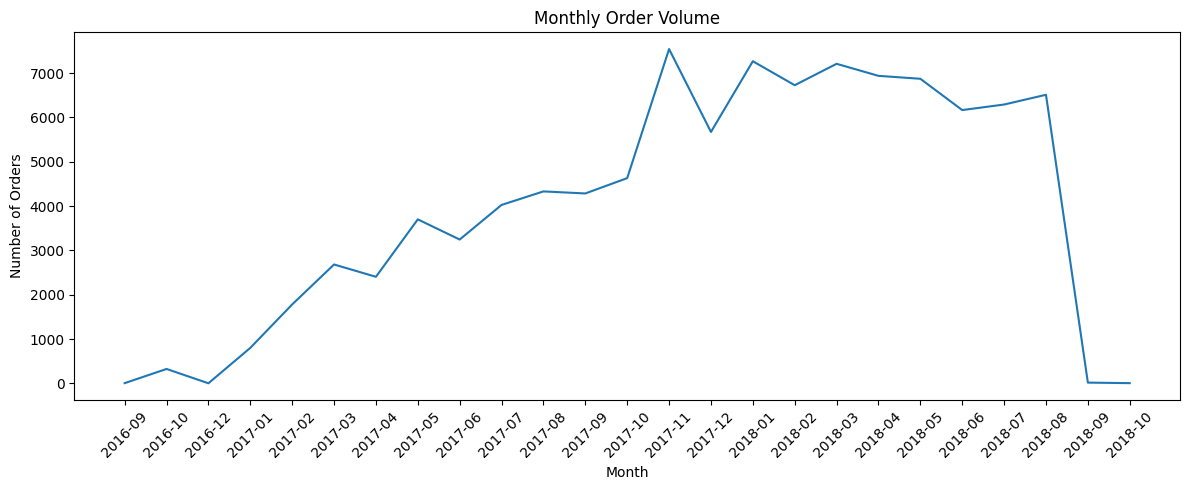

In [127]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_orders["purchase_month"],
    monthly_orders["total_orders"]
)

plt.title("Monthly Order Volume")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [128]:
monthly_revenue = (
    clean_orders
    .groupby("purchase_month")
    .agg(
        total_orders=("order_id", "nunique"),
        total_revenue=("total_payment_value", "sum")
    )
    .reset_index()
)

monthly_revenue["AOV"] = (
    monthly_revenue["total_revenue"]
    / monthly_revenue["total_orders"]
)

monthly_revenue["AOV"] = monthly_revenue["AOV"].round(2)

display(monthly_revenue)


,purchase_month,total_orders,total_revenue,AOV
0,2016-09,4,252.24,63.06
1,2016-10,324,59090.48,182.38
2,2016-12,1,19.62,19.62
3,2017-01,800,138488.04,173.11
4,2017-02,1780,291908.01,163.99
5,2017-03,2682,449863.60,167.73
6,2017-04,2404,417788.03,173.79
7,2017-05,3700,592918.82,160.25
8,2017-06,3245,511276.38,157.56
9,2017-07,4026,592382.92,147.14


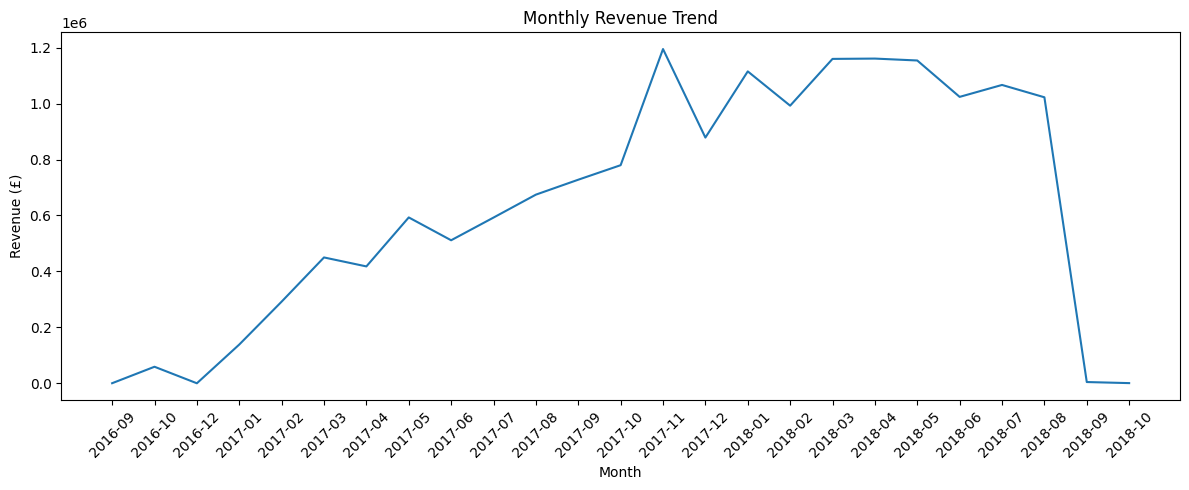

In [129]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_revenue["purchase_month"],
    monthly_revenue["total_revenue"]
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

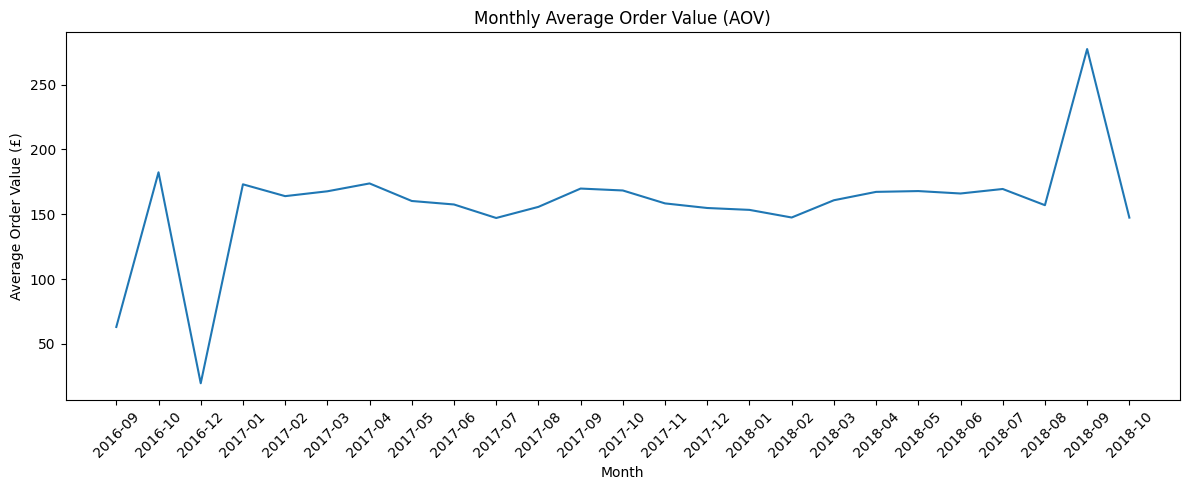

In [130]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_revenue["purchase_month"],
    monthly_revenue["AOV"]
)

plt.title("Monthly Average Order Value (AOV)")
plt.xlabel("Month")
plt.ylabel("Average Order Value (£)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [131]:
highest_revenue_month = monthly_revenue.loc[
    monthly_revenue["total_revenue"].idxmax()
]

lowest_revenue_month = monthly_revenue.loc[
    monthly_revenue["total_revenue"].idxmin()
]

print("Highest revenue month:")
display(highest_revenue_month)

print("\nLowest revenue month:")
display(lowest_revenue_month)

Highest revenue month:


purchase_month      2017-11
total_orders           7544
total_revenue     1194882.8
AOV                  158.39
Name: 13, dtype: object


Lowest revenue month:


purchase_month    2016-12
total_orders            1
total_revenue       19.62
AOV                 19.62
Name: 2, dtype: object

In [132]:
monthly_revenue.to_csv(
    "../data/processed/monthly_revenue_analysis.csv",
    index=False
)

print("Monthly revenue analysis saved successfully.")

Monthly revenue analysis saved successfully.


In [133]:
customer_summary = (
    clean_orders
    .groupby("customer_unique_id")
    .agg(
        total_orders=("order_id", "nunique"),
        total_spend=("total_payment_value", "sum"),
        avg_order_value=("total_payment_value", "mean"),
        total_items=("total_items", "sum"),
        avg_review_score=("review_score", "mean"),
        total_freight=("total_freight_value", "sum")
    )
    .reset_index()
)

display(customer_summary.head())

,customer_unique_id,total_orders,total_spend,avg_order_value,total_items,avg_review_score,total_freight
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,141.90,1.0,5.0,12.00
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,27.19,1.0,4.0,8.29
2,0000f46a3911fa3c0805444483337064,1,86.22,86.22,1.0,3.0,17.22
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62,43.62,1.0,4.0,17.63
4,0004aac84e0df4da2b147fca70cf8255,1,196.89,196.89,1.0,5.0,16.89


In [134]:
print("Total customers:", len(customer_summary))
print(
    "Unique customer IDs:",
    customer_summary["customer_unique_id"].nunique()
)

Total customers: 96096
Unique customer IDs: 96096


In [135]:
customer_summary.describe().T

,count,mean,std,min,25%,50%,75%,max
total_orders,96096.0,1.034809,0.214384,1.0,1.00,1.00,1.00,17.00
total_spend,96096.0,166.592492,231.428332,0.0,63.12,108.00,183.53,13664.08
avg_order_value,96095.0,161.401796,222.308078,0.0,62.46,105.83,177.21,13664.08
total_items,96096.0,1.172265,0.627071,0.0,1.00,1.00,1.00,24.00
avg_review_score,96096.0,4.053708,1.382446,0.0,4.00,5.00,5.00,5.00
total_freight,96096.0,23.433957,22.883215,0.0,13.92,17.53,25.42,1794.96


In [136]:
customer_summary["is_repeat_customer"] = (
    customer_summary["total_orders"] > 1
).astype(int)

In [137]:
customer_summary["is_repeat_customer"].value_counts()

is_repeat_customer
0    93099
1     2997
Name: count, dtype: int64

In [138]:
repeat_customer_rate = (
    customer_summary["is_repeat_customer"].mean() * 100
)

print(
    f"Repeat customer rate: {repeat_customer_rate:.2f}%"
)

Repeat customer rate: 3.12%


In [139]:
purchase_frequency = (
    customer_summary["total_orders"]
    .value_counts()
    .sort_index()
)

display(purchase_frequency.head(20))

total_orders
1     93099
2      2745
3       203
4        30
5         8
6         6
7         3
9         1
17        1
Name: count, dtype: int64

Task was destroyed but it is pending!
task: <Task pending name='Task-560' coro=<_async_in_context.<locals>.run_in_context() done, defined at C:\Users\jashw\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\ipykernel\utils.py:57> wait_for=<Task pending name='Task-561' coro=<Kernel.shell_main() running at C:\Users\jashw\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\Users\jashw\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\zmq\eventloop\zmqstream.py:563]>
C:\Users\jashw\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\matplotlib\transforms.py:195: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  ref = weakref.ref(
Task was destroyed but it is pending!
task: <Task pending name='Task-561' coro=<Kernel.shell_main() running at C:\Users\jashw\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\ipykernel\kernelbase.py:597> 

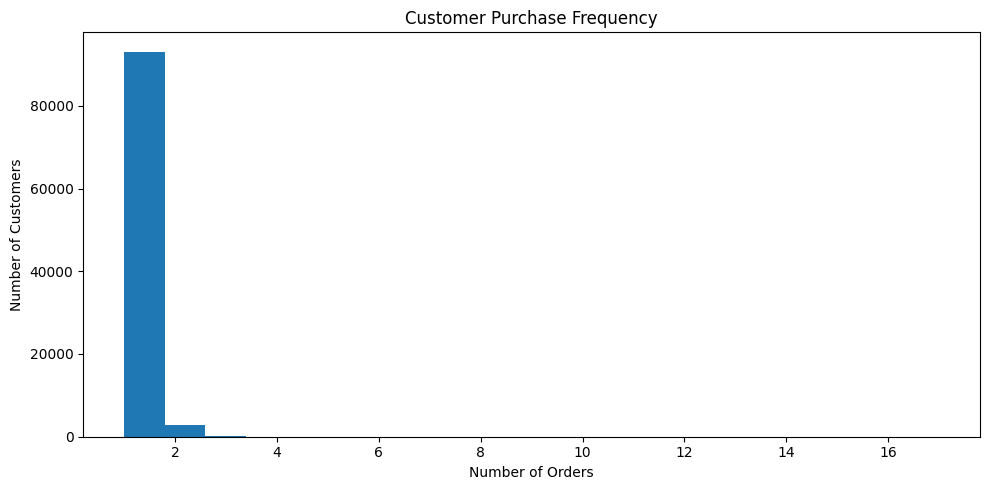

In [140]:
plt.figure(figsize=(10, 5))

plt.hist(
    customer_summary["total_orders"],
    bins=20
)

plt.title("Customer Purchase Frequency")
plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

In [141]:
customer_summary.to_csv(
    "../data/processed/customer_summary.csv",
    index=False
)

print("Customer summary saved successfully.")

Customer summary saved successfully.


In [142]:
reference_date = (
    clean_orders["order_purchase_timestamp"].max()
)

print("Reference date:", reference_date)

Reference date: 2018-10-17 17:30:18


In [143]:
customer_recency = (
    clean_orders
    .groupby("customer_unique_id")
    .agg(
        last_purchase_date=(
            "order_purchase_timestamp",
            "max"
        )
    )
    .reset_index()
)

display(customer_recency.head())

,customer_unique_id,last_purchase_date
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42


In [144]:
customer_recency["recency_days"] = (
    reference_date
    - customer_recency["last_purchase_date"]
).dt.days

display(customer_recency.head())

,customer_unique_id,last_purchase_date,recency_days
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,160
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,163
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,585
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,369
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,336


In [145]:
customer_recency["recency_days"].describe()

count    96096.000000
mean       287.735691
std        153.414676
min          0.000000
25%        163.000000
50%        268.000000
75%        397.000000
max        772.000000
Name: recency_days, dtype: float64

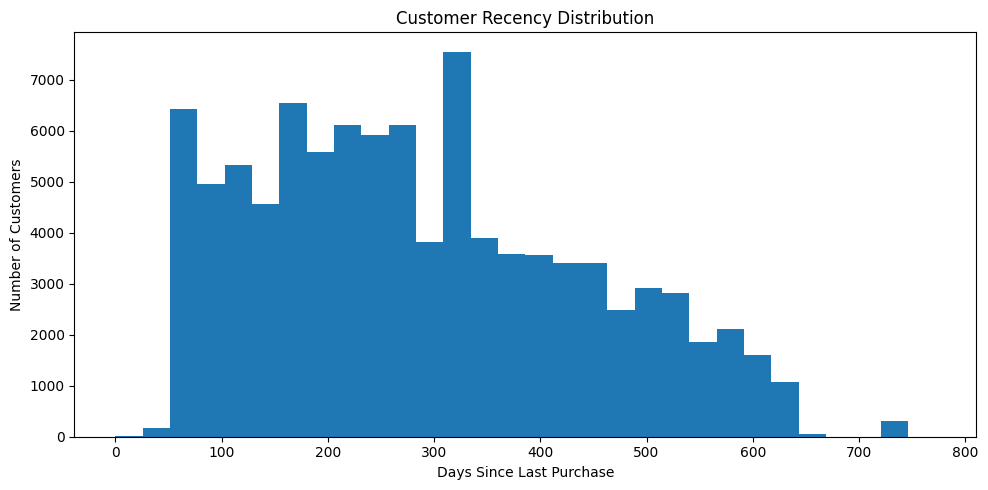

In [146]:
plt.figure(figsize=(10, 5))

plt.hist(
    customer_recency["recency_days"],
    bins=30
)

plt.title("Customer Recency Distribution")
plt.xlabel("Days Since Last Purchase")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

In [147]:
customer_summary = customer_summary.merge(
    customer_recency,
    on="customer_unique_id",
    how="left"
)

display(customer_summary.head())

,customer_unique_id,total_orders,total_spend,avg_order_value,total_items,avg_review_score,total_freight,is_repeat_customer,last_purchase_date,recency_days
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,141.90,1.0,5.0,12.00,0,2018-05-10 10:56:27,160
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,27.19,1.0,4.0,8.29,0,2018-05-07 11:11:27,163
2,0000f46a3911fa3c0805444483337064,1,86.22,86.22,1.0,3.0,17.22,0,2017-03-10 21:05:03,585
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62,43.62,1.0,4.0,17.63,0,2017-10-12 20:29:41,369
4,0004aac84e0df4da2b147fca70cf8255,1,196.89,196.89,1.0,5.0,16.89,0,2017-11-14 19:45:42,336


In [148]:
print(
    "Missing recency values:",
    customer_summary["recency_days"].isna().sum()
)

Missing recency values: 0


In [149]:
customer_summary.to_csv(
    "../data/processed/customer_summary_recency.csv",
    index=False
)

print("Customer recency analysis saved successfully.")

Customer recency analysis saved successfully.


Frequency Analysis

In [150]:
customer_frequency = (
    clean_orders
    .groupby("customer_unique_id")
    .agg(
        frequency=("order_id", "nunique")
    )
    .reset_index()
)

display(customer_frequency.head())

,customer_unique_id,frequency
0,0000366f3b9a7992bf8c76cfdf3221e2,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1
2,0000f46a3911fa3c0805444483337064,1
3,0000f6ccb0745a6a4b88665a16c9f078,1
4,0004aac84e0df4da2b147fca70cf8255,1


In [151]:
customer_frequency["frequency"].describe()

count    96096.000000
mean         1.034809
std          0.214384
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         17.000000
Name: frequency, dtype: float64

In [152]:
frequency_counts = (
    customer_frequency["frequency"]
    .value_counts()
    .sort_index()
)

display(frequency_counts.head(20))

frequency
1     93099
2      2745
3       203
4        30
5         8
6         6
7         3
9         1
17        1
Name: count, dtype: int64

In [153]:
repeat_rate = (
    customer_frequency["frequency"].gt(1).mean() * 100
)

print(
    f"Repeat purchase rate: {repeat_rate:.2f}%"
)

Repeat purchase rate: 3.12%


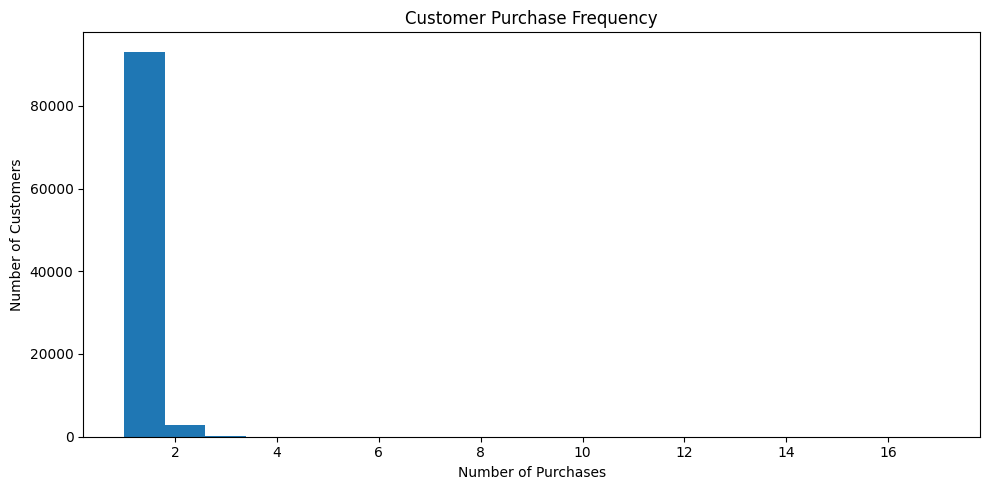

In [154]:
plt.figure(figsize=(10, 5))

plt.hist(
    customer_frequency["frequency"],
    bins=20
)

plt.title("Customer Purchase Frequency")
plt.xlabel("Number of Purchases")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

In [155]:
customer_summary = customer_summary.merge(
    customer_frequency,
    on="customer_unique_id",
    how="left"
)

display(
    customer_summary[
        [
            "customer_unique_id",
            "recency_days",
            "frequency"
        ]
    ].head()
)

,customer_unique_id,recency_days,frequency
0,0000366f3b9a7992bf8c76cfdf3221e2,160,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,163,1
2,0000f46a3911fa3c0805444483337064,585,1
3,0000f6ccb0745a6a4b88665a16c9f078,369,1
4,0004aac84e0df4da2b147fca70cf8255,336,1


In [156]:
print(
    "Missing frequency:",
    customer_summary["frequency"].isna().sum()
)

Missing frequency: 0


In [157]:
customer_summary.to_csv(
    "../data/processed/customer_summary_rfm_base.csv",
    index=False
)

print("Frequency analysis completed successfully.")

Frequency analysis completed successfully.


In [158]:
customer_monetary = (
    clean_orders
    .groupby("customer_unique_id")
    .agg(
        monetary=("total_payment_value", "sum")
    )
    .reset_index()
)

display(customer_monetary.head())

,customer_unique_id,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,27.19
2,0000f46a3911fa3c0805444483337064,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,43.62
4,0004aac84e0df4da2b147fca70cf8255,196.89


In [159]:
customer_monetary["monetary"].describe()

count    96096.000000
mean       166.592492
std        231.428332
min          0.000000
25%         63.120000
50%        108.000000
75%        183.530000
max      13664.080000
Name: monetary, dtype: float64

In [160]:
top_customers = (
    customer_monetary
    .sort_values(
        "monetary",
        ascending=False
    )
    .head(20)
)

display(top_customers)

,customer_unique_id,monetary
3826,0a0a92112bd4c708ca5fde585afaa872,13664.08
26456,46450c74a0d8c5ca9395da1daac6c120,9553.02
81962,da122df9eeddfedc1dc1f5349a1a690c,7571.63
44447,763c8b1c9c68a0229c42c9fc6f662b93,7274.88
82808,dc4802a71eae9be1dd28f5d788ceb526,6929.31
26205,459bef486812aa25204be022145caa62,6922.21
95806,ff4159b92c40ebe40454e3e6a7c35ed6,6726.66
24121,4007669dec559734d6f53e029e360987,6081.54
35070,5d0a2980b292d049061542014e8960bf,4809.44
89688,eebb5dda148d3893cdaf5b5ca3040ccb,4764.34


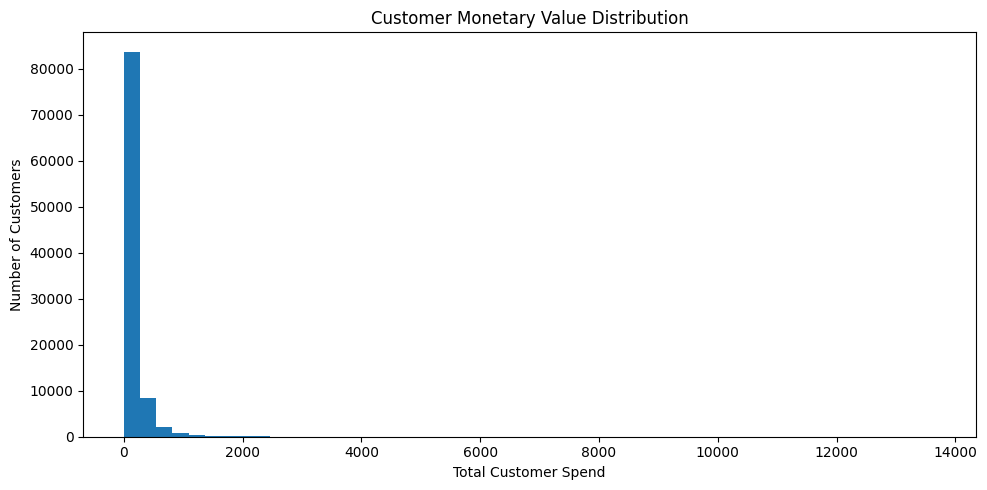

In [161]:
plt.figure(figsize=(10, 5))

plt.hist(
    customer_monetary["monetary"],
    bins=50
)

plt.title("Customer Monetary Value Distribution")
plt.xlabel("Total Customer Spend")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

In [162]:
customer_summary = customer_summary.merge(
    customer_monetary,
    on="customer_unique_id",
    how="left"
)

display(
    customer_summary[
        [
            "customer_unique_id",
            "recency_days",
            "frequency",
            "monetary"
        ]
    ].head()
)

,customer_unique_id,recency_days,frequency,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,160,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,163,1,27.19
2,0000f46a3911fa3c0805444483337064,585,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,369,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,336,1,196.89


In [163]:
print(
    "Missing monetary values:",
    customer_summary["monetary"].isna().sum()
)

Missing monetary values: 0


In [164]:
customer_summary.to_csv(
    "../data/processed/customer_rfm_base.csv",
    index=False
)

print("RFM base dataset saved successfully.")

RFM base dataset saved successfully.


In [165]:
rfm = customer_summary[
    [
        "customer_unique_id",
        "recency_days",
        "frequency",
        "monetary"
    ]
].copy()

display(rfm.head())

,customer_unique_id,recency_days,frequency,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,160,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,163,1,27.19
2,0000f46a3911fa3c0805444483337064,585,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,369,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,336,1,196.89


In [166]:
rfm["R_score"] = pd.qcut(
    rfm["recency_days"],
    q=5,
    labels=[5, 4, 3, 2, 1],
    duplicates="drop"
)

In [167]:
rfm["F_score"] = pd.qcut(
    rfm["frequency"].rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5]
)

In [168]:
rfm["M_score"] = pd.qcut(
    rfm["monetary"].rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5]
)

In [169]:
rfm["R_score"] = rfm["R_score"].astype(int)
rfm["F_score"] = rfm["F_score"].astype(int)
rfm["M_score"] = rfm["M_score"].astype(int)

In [170]:
rfm["RFM_score"] = (
    rfm["R_score"].astype(str)
    + rfm["F_score"].astype(str)
    + rfm["M_score"].astype(str)
)

In [171]:
display(
    rfm[
        [
            "customer_unique_id",
            "recency_days",
            "frequency",
            "monetary",
            "R_score",
            "F_score",
            "M_score"
        ]
    ].head(20)
)

,customer_unique_id,recency_days,frequency,monetary,R_score,F_score,M_score
0,0000366f3b9a7992bf8c76cfdf3221e2,160,1,141.90,4,1,4
1,0000b849f77a49e4a4ce2b2a4ca5be3f,163,1,27.19,4,1,1
2,0000f46a3911fa3c0805444483337064,585,1,86.22,1,1,2
3,0000f6ccb0745a6a4b88665a16c9f078,369,1,43.62,2,1,1
4,0004aac84e0df4da2b147fca70cf8255,336,1,196.89,2,1,4
5,0004bd2a26a76fe21f786e4fbd80607f,194,1,166.98,4,1,4
6,00050ab1314c0e55a6ca13cf7181fecf,180,1,35.38,4,1,1
7,00053a61a98854899e70ed204dd4bafe,231,1,419.18,3,1,5
8,0005e1862207bf6ccc02e4228effd9a0,591,1,150.12,1,1,4
9,0005ef4cd20d2893f0d9fbd94d3c0d97,219,1,129.76,4,1,3


In [172]:
rfm["RFM_score"] = (
    rfm["R_score"].astype(str)
    + rfm["F_score"].astype(str)
    + rfm["M_score"].astype(str)
)

rfm["RFM_total"] = (
    rfm["R_score"]
    + rfm["F_score"]
    + rfm["M_score"]
)

display(
    rfm[
        [
            "customer_unique_id",
            "R_score",
            "F_score",
            "M_score",
            "RFM_score",
            "RFM_total"
        ]
    ].head(20)
)

,customer_unique_id,R_score,F_score,M_score,RFM_score,RFM_total
0,0000366f3b9a7992bf8c76cfdf3221e2,4,1,4,414,9
1,0000b849f77a49e4a4ce2b2a4ca5be3f,4,1,1,411,6
2,0000f46a3911fa3c0805444483337064,1,1,2,112,4
3,0000f6ccb0745a6a4b88665a16c9f078,2,1,1,211,4
4,0004aac84e0df4da2b147fca70cf8255,2,1,4,214,7
5,0004bd2a26a76fe21f786e4fbd80607f,4,1,4,414,9
6,00050ab1314c0e55a6ca13cf7181fecf,4,1,1,411,6
7,00053a61a98854899e70ed204dd4bafe,3,1,5,315,9
8,0005e1862207bf6ccc02e4228effd9a0,1,1,4,114,6
9,0005ef4cd20d2893f0d9fbd94d3c0d97,4,1,3,413,8


In [173]:
def assign_segment(row):

    r = row["R_score"]
    f = row["F_score"]
    m = row["M_score"]

    # High-value and active customers
    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"

    # Recent and valuable customers
    elif r >= 4 and m >= 4:
        return "High Value Active"

    # Frequent purchasers
    elif f >= 4:
        return "Loyal Customers"

    # High spending but becoming inactive
    elif r <= 2 and m >= 4:
        return "At Risk High Value"

    # Customers who haven't purchased recently
    elif r <= 2:
        return "At Risk"

    # Low-value customers
    elif r <= 3 and f <= 2 and m <= 2:
        return "Low Value"

    else:
        return "Potential Loyal"

In [174]:
rfm["customer_segment"] = rfm.apply(
    assign_segment,
    axis=1
)

display(
    rfm[
        [
            "customer_unique_id",
            "R_score",
            "F_score",
            "M_score",
            "RFM_score",
            "RFM_total",
            "customer_segment"
        ]
    ].head(20)
)

,customer_unique_id,R_score,F_score,M_score,RFM_score,RFM_total,customer_segment
0,0000366f3b9a7992bf8c76cfdf3221e2,4,1,4,414,9,High Value Active
1,0000b849f77a49e4a4ce2b2a4ca5be3f,4,1,1,411,6,Potential Loyal
2,0000f46a3911fa3c0805444483337064,1,1,2,112,4,At Risk
3,0000f6ccb0745a6a4b88665a16c9f078,2,1,1,211,4,At Risk
4,0004aac84e0df4da2b147fca70cf8255,2,1,4,214,7,At Risk High Value
5,0004bd2a26a76fe21f786e4fbd80607f,4,1,4,414,9,High Value Active
6,00050ab1314c0e55a6ca13cf7181fecf,4,1,1,411,6,Potential Loyal
7,00053a61a98854899e70ed204dd4bafe,3,1,5,315,9,Potential Loyal
8,0005e1862207bf6ccc02e4228effd9a0,1,1,4,114,6,At Risk High Value
9,0005ef4cd20d2893f0d9fbd94d3c0d97,4,1,3,413,8,Potential Loyal


In [175]:
segment_counts = (
    rfm["customer_segment"]
    .value_counts()
    .reset_index()
)

segment_counts.columns = [
    "customer_segment",
    "customer_count"
]

display(segment_counts)

,customer_segment,customer_count
0,Loyal Customers,31726
1,Potential Loyal,22226
2,At Risk,14357
3,High Value Active,9204
4,At Risk High Value,8788
5,Champions,6712
6,Low Value,3083


In [176]:
segment_counts["percentage"] = (
    segment_counts["customer_count"]
    / len(rfm)
    * 100
).round(2)

display(segment_counts)

,customer_segment,customer_count,percentage
0,Loyal Customers,31726,33.01
1,Potential Loyal,22226,23.13
2,At Risk,14357,14.94
3,High Value Active,9204,9.58
4,At Risk High Value,8788,9.15
5,Champions,6712,6.98
6,Low Value,3083,3.21


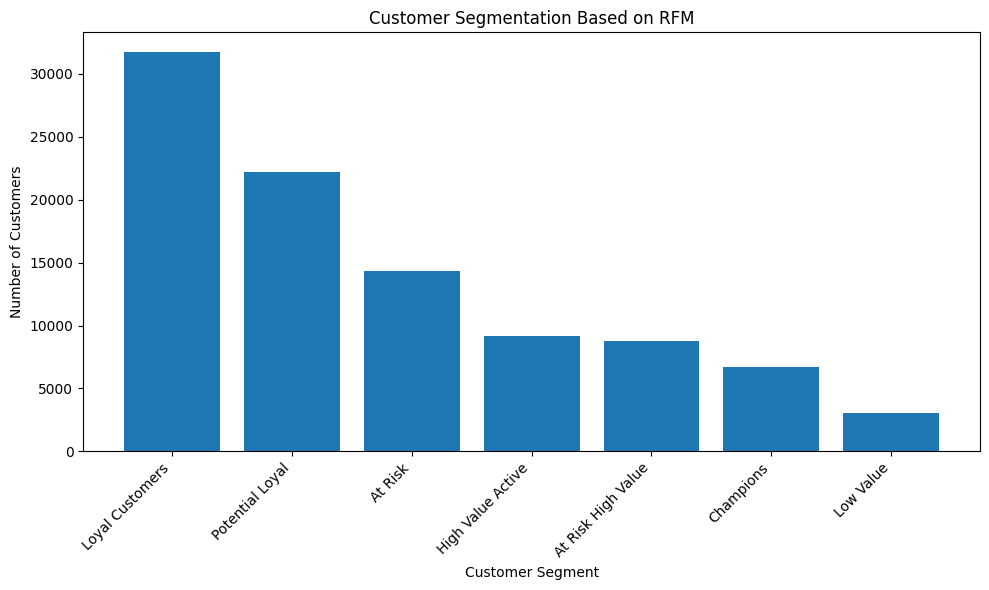

In [177]:
plt.figure(figsize=(10, 6))

plt.bar(
    segment_counts["customer_segment"],
    segment_counts["customer_count"]
)

plt.title("Customer Segmentation Based on RFM")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [178]:
segment_value = (
    rfm.groupby("customer_segment")
    .agg(
        customers=("customer_unique_id", "nunique"),
        total_revenue=("monetary", "sum"),
        avg_customer_value=("monetary", "mean")
    )
    .reset_index()
    .sort_values(
        "total_revenue",
        ascending=False
    )
)

display(segment_value)

,customer_segment,customers,total_revenue,avg_customer_value
5,Loyal Customers,31726,4524869.68,142.623390
3,High Value Active,9204,2801902.06,304.422214
1,At Risk High Value,8788,2750081.56,312.935999
6,Potential Loyal,22226,2587394.00,116.412940
2,Champions,6712,2131028.81,317.495353
0,At Risk,14357,1045816.06,72.843634
4,Low Value,3083,167779.95,54.421002


In [179]:
rfm.to_csv(
    "../data/processed/customer_segments.csv",
    index=False
)

segment_value.to_csv(
    "../data/processed/segment_business_value.csv",
    index=False
)

print("Customer segmentation completed successfully.")

Customer segmentation completed successfully.


In [180]:
segment_actions = {
    "Champions": "Reward loyalty, provide exclusive offers, and encourage referrals",

    "High Value Active": "Protect relationship with personalized offers and premium services",

    "Loyal Customers": "Use loyalty programs, cross-selling, and personalized recommendations",

    "At Risk High Value": "Launch targeted win-back campaigns and personalized incentives",

    "At Risk": "Send re-engagement campaigns and limited-time offers",

    "Low Value": "Use low-cost promotions and product recommendations",

    "Potential Loyal": "Encourage repeat purchases through personalized offers"
}

In [181]:
rfm["recommended_action"] = (
    rfm["customer_segment"]
    .map(segment_actions)
)

In [182]:
display(
    rfm[
        [
            "customer_unique_id",
            "customer_segment",
            "RFM_total",
            "recommended_action"
        ]
    ].head(20)
)

,customer_unique_id,customer_segment,RFM_total,recommended_action
0,0000366f3b9a7992bf8c76cfdf3221e2,High Value Active,9,Protect relationship with personalized offers ...
1,0000b849f77a49e4a4ce2b2a4ca5be3f,Potential Loyal,6,Encourage repeat purchases through personalize...
2,0000f46a3911fa3c0805444483337064,At Risk,4,Send re-engagement campaigns and limited-time ...
3,0000f6ccb0745a6a4b88665a16c9f078,At Risk,4,Send re-engagement campaigns and limited-time ...
4,0004aac84e0df4da2b147fca70cf8255,At Risk High Value,7,Launch targeted win-back campaigns and persona...
5,0004bd2a26a76fe21f786e4fbd80607f,High Value Active,9,Protect relationship with personalized offers ...
6,00050ab1314c0e55a6ca13cf7181fecf,Potential Loyal,6,Encourage repeat purchases through personalize...
7,00053a61a98854899e70ed204dd4bafe,Potential Loyal,9,Encourage repeat purchases through personalize...
8,0005e1862207bf6ccc02e4228effd9a0,At Risk High Value,6,Launch targeted win-back campaigns and persona...
9,0005ef4cd20d2893f0d9fbd94d3c0d97,Potential Loyal,8,Encourage repeat purchases through personalize...


In [183]:
action_summary = (
    rfm.groupby(
        ["customer_segment", "recommended_action"]
    )
    .agg(
        customer_count=("customer_unique_id", "nunique"),
        total_revenue=("monetary", "sum"),
        avg_customer_value=("monetary", "mean")
    )
    .reset_index()
    .sort_values(
        "total_revenue",
        ascending=False
    )
)

display(action_summary)

,customer_segment,recommended_action,customer_count,total_revenue,avg_customer_value
5,Loyal Customers,"Use loyalty programs, cross-selling, and perso...",31726,4524869.68,142.623390
3,High Value Active,Protect relationship with personalized offers ...,9204,2801902.06,304.422214
1,At Risk High Value,Launch targeted win-back campaigns and persona...,8788,2750081.56,312.935999
6,Potential Loyal,Encourage repeat purchases through personalize...,22226,2587394.00,116.412940
2,Champions,"Reward loyalty, provide exclusive offers, and ...",6712,2131028.81,317.495353
0,At Risk,Send re-engagement campaigns and limited-time ...,14357,1045816.06,72.843634
4,Low Value,Use low-cost promotions and product recommenda...,3083,167779.95,54.421002


In [184]:
highest_value_segment = (
    action_summary
    .sort_values(
        "total_revenue",
        ascending=False
    )
    .iloc[0]
)

print("Highest-value segment:")
print(
    highest_value_segment[
        [
            "customer_segment",
            "customer_count",
            "total_revenue",
            "recommended_action"
        ]
    ]
)

Highest-value segment:
customer_segment                                        Loyal Customers
customer_count                                                    31726
total_revenue                                                4524869.68
recommended_action    Use loyalty programs, cross-selling, and perso...
Name: 5, dtype: object


In [185]:
rfm.to_csv(
    "../data/processed/customer_decision_segments.csv",
    index=False
)

action_summary.to_csv(
    "../data/processed/business_action_summary.csv",
    index=False
)

print("Business recommendations saved successfully.")

Business recommendations saved successfully.


In [186]:
print(products.shape)
display(products.head())
print(products.columns.tolist())

(32951, 9)


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']


In [187]:
order_product = order_items.merge(
    products,
    on="product_id",
    how="left"
)

print(order_product.shape)
display(order_product.head())

(112650, 15)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0


In [188]:
order_product = order_product.merge(
    category_translation,
    on="product_category_name",
    how="left"
)

display(
    order_product[
        [
            "product_id",
            "product_category_name",
            "product_category_name_english"
        ]
    ].head(10)
)

,product_id,product_category_name,product_category_name_english
0,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,cool_stuff
1,e5f2d52b802189ee658865ca93d83a8f,pet_shop,pet_shop
2,c777355d18b72b67abbeef9df44fd0fd,moveis_decoracao,furniture_decor
3,7634da152a4610f1595efa32f14722fc,perfumaria,perfumery
4,ac6c3623068f30de03045865e4e10089,ferramentas_jardim,garden_tools
5,ef92defde845ab8450f9d70c526ef70f,utilidades_domesticas,housewares
6,8d4f2bb7e93e6710a28f34fa83ee7d28,telefonia,telephony
7,557d850972a7d6f792fd18ae1400d9b6,ferramentas_jardim,garden_tools
8,310ae3c140ff94b03219ad0adc3c778f,beleza_saude,health_beauty
9,4535b0e1091c278dfd193e5a1d63b39f,livros_tecnicos,books_technical


In [189]:
print(order_product[["price", "freight_value"]].describe())

               price  freight_value
count  112650.000000  112650.000000
mean      120.653739      19.990320
std       183.633928      15.806405
min         0.850000       0.000000
25%        39.900000      13.080000
50%        74.990000      16.260000
75%       134.900000      21.150000
max      6735.000000     409.680000


In [190]:
category_analysis = (
    order_product
    .groupby("product_category_name_english")
    .agg(
        orders=("order_id", "nunique"),
        products_sold=("product_id", "count"),
        revenue=("price", "sum"),
        avg_price=("price", "mean")
    )
    .reset_index()
)

In [191]:
category_analysis = category_analysis.sort_values(
    "revenue",
    ascending=False
)

display(category_analysis.head(20))

,product_category_name_english,orders,products_sold,revenue,avg_price
43,health_beauty,8836,9670,1258681.34,130.163531
70,watches_gifts,5624,5991,1205005.68,201.135984
7,bed_bath_table,9417,11115,1036988.68,93.296327
65,sports_leisure,7720,8641,988048.97,114.344285
15,computers_accessories,6689,7827,911954.32,116.513903
39,furniture_decor,6449,8334,729762.49,87.564494
20,cool_stuff,3632,3796,635290.85,167.357969
49,housewares,5884,6964,632248.66,90.788148
5,auto,3897,4235,592720.11,139.957523
42,garden_tools,3518,4347,485256.46,111.630196


In [192]:
top_categories = category_analysis.head(10)

display(top_categories)

,product_category_name_english,orders,products_sold,revenue,avg_price
43,health_beauty,8836,9670,1258681.34,130.163531
70,watches_gifts,5624,5991,1205005.68,201.135984
7,bed_bath_table,9417,11115,1036988.68,93.296327
65,sports_leisure,7720,8641,988048.97,114.344285
15,computers_accessories,6689,7827,911954.32,116.513903
39,furniture_decor,6449,8334,729762.49,87.564494
20,cool_stuff,3632,3796,635290.85,167.357969
49,housewares,5884,6964,632248.66,90.788148
5,auto,3897,4235,592720.11,139.957523
42,garden_tools,3518,4347,485256.46,111.630196


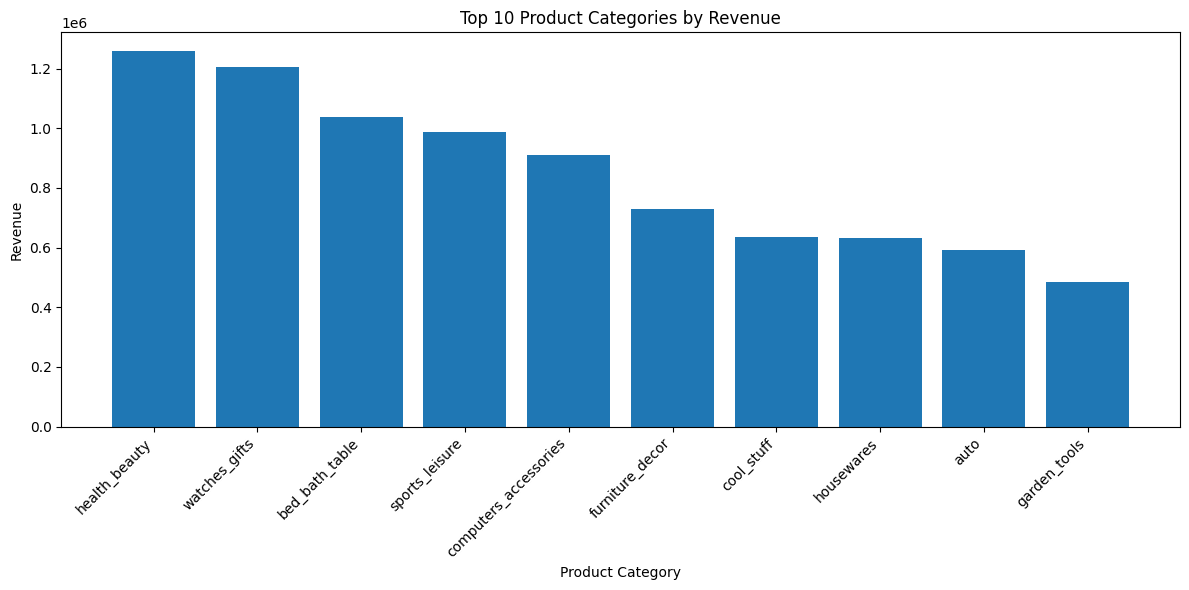

In [193]:
plt.figure(figsize=(12, 6))

plt.bar(
    top_categories["product_category_name_english"],
    top_categories["revenue"]
)

plt.title("Top 10 Product Categories by Revenue")
plt.xlabel("Product Category")
plt.ylabel("Revenue")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [194]:
top_volume_categories = (
    category_analysis
    .sort_values(
        "products_sold",
        ascending=False
    )
    .head(10)
)

display(top_volume_categories)

,product_category_name_english,orders,products_sold,revenue,avg_price
7,bed_bath_table,9417,11115,1036988.68,93.296327
43,health_beauty,8836,9670,1258681.34,130.163531
65,sports_leisure,7720,8641,988048.97,114.344285
39,furniture_decor,6449,8334,729762.49,87.564494
15,computers_accessories,6689,7827,911954.32,116.513903
49,housewares,5884,6964,632248.66,90.788148
70,watches_gifts,5624,5991,1205005.68,201.135984
68,telephony,4199,4545,323667.53,71.213978
42,garden_tools,3518,4347,485256.46,111.630196
5,auto,3897,4235,592720.11,139.957523


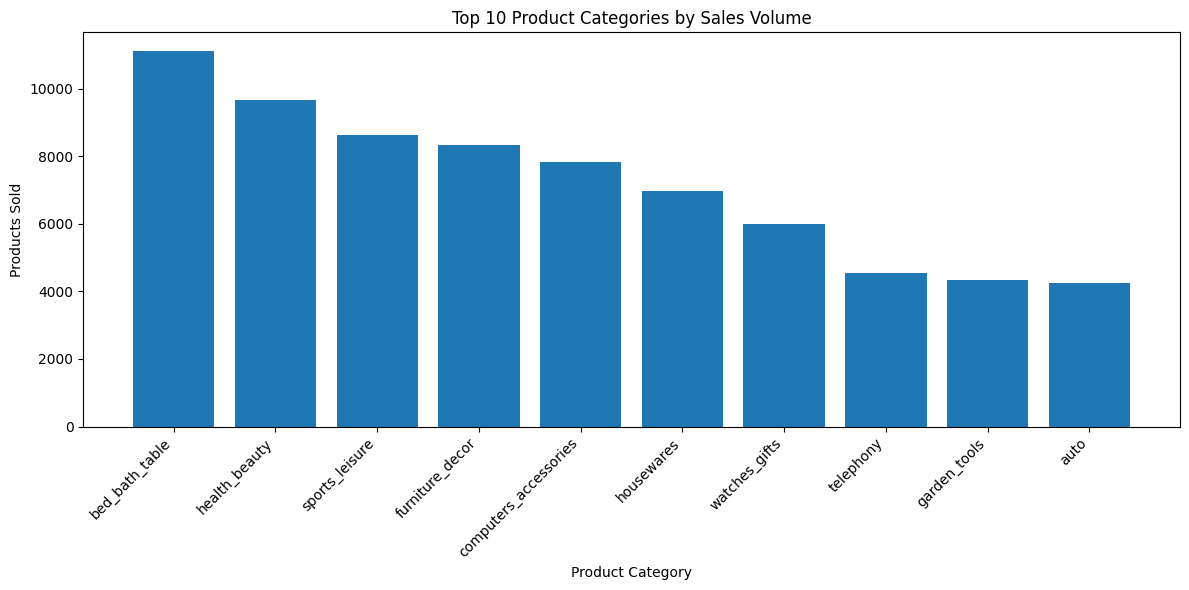

In [195]:
plt.figure(figsize=(12, 6))

plt.bar(
    top_volume_categories["product_category_name_english"],
    top_volume_categories["products_sold"]
)

plt.title("Top 10 Product Categories by Sales Volume")
plt.xlabel("Product Category")
plt.ylabel("Products Sold")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [196]:
category_analysis.to_csv(
    "../data/processed/category_analysis.csv",
    index=False
)

print("Product and category analysis completed successfully.")

Product and category analysis completed successfully.


In [197]:
print("First purchase:")
print(clean_orders["order_purchase_timestamp"].min())

print("\nLast purchase:")
print(clean_orders["order_purchase_timestamp"].max())

First purchase:
2016-09-04 21:15:19

Last purchase:
2018-10-17 17:30:18


In [198]:
retention = (
    clean_orders
    .groupby("customer_unique_id")
    .agg(
        last_purchase_date=("order_purchase_timestamp", "max"),
        total_orders=("order_id", "nunique"),
        total_spend=("total_payment_value", "sum")
    )
    .reset_index()
)

display(retention.head())

,customer_unique_id,last_purchase_date,total_orders,total_spend
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,1,27.19
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,1,196.89


In [199]:
reference_date = clean_orders["order_purchase_timestamp"].max()

retention["days_since_last_purchase"] = (
    reference_date
    - retention["last_purchase_date"]
).dt.days

display(retention.head())

,customer_unique_id,last_purchase_date,total_orders,total_spend,days_since_last_purchase
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,1,141.90,160
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,1,27.19,163
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,1,86.22,585
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,1,43.62,369
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,1,196.89,336


In [200]:
retention["days_since_last_purchase"].describe()

count    96096.000000
mean       287.735691
std        153.414676
min          0.000000
25%        163.000000
50%        268.000000
75%        397.000000
max        772.000000
Name: days_since_last_purchase, dtype: float64

In [201]:
retention["churned"] = (
    retention["days_since_last_purchase"] > 90
).astype(int)

In [202]:
churn_counts = retention["churned"].value_counts()

display(churn_counts)

churned
1    86432
0     9664
Name: count, dtype: int64

In [203]:
churn_rate = (
    retention["churned"].mean() * 100
)

print(f"Churn rate: {churn_rate:.2f}%")

Churn rate: 89.94%


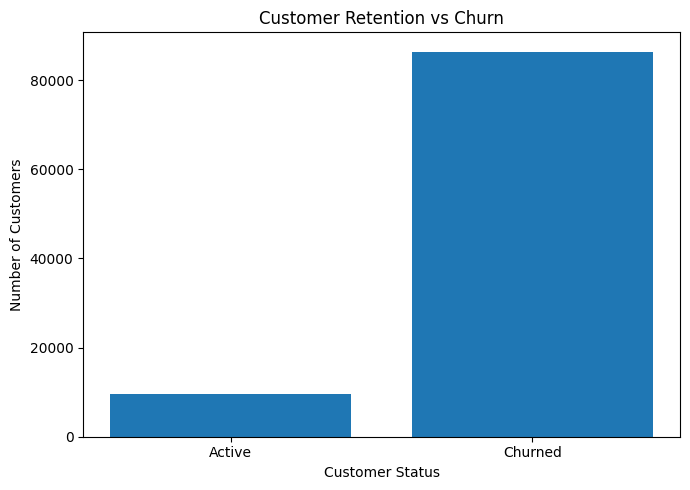

In [204]:
plt.figure(figsize=(7, 5))

plt.bar(
    ["Active", "Churned"],
    [
        (retention["churned"] == 0).sum(),
        (retention["churned"] == 1).sum()
    ]
)

plt.title("Customer Retention vs Churn")
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [205]:
retention.to_csv(
    "../data/processed/customer_retention_base.csv",
    index=False
)

print("Customer retention base dataset saved successfully.")

Customer retention base dataset saved successfully.


In [206]:
ml_features = customer_summary.copy()

print("Shape:", ml_features.shape)
display(ml_features.head())

Shape: (96096, 12)


,customer_unique_id,total_orders,total_spend,avg_order_value,total_items,avg_review_score,total_freight,is_repeat_customer,last_purchase_date,recency_days,frequency,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,141.90,1.0,5.0,12.00,0,2018-05-10 10:56:27,160,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,27.19,1.0,4.0,8.29,0,2018-05-07 11:11:27,163,1,27.19
2,0000f46a3911fa3c0805444483337064,1,86.22,86.22,1.0,3.0,17.22,0,2017-03-10 21:05:03,585,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62,43.62,1.0,4.0,17.63,0,2017-10-12 20:29:41,369,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,1,196.89,196.89,1.0,5.0,16.89,0,2017-11-14 19:45:42,336,1,196.89


In [207]:
feature_columns = [
    "customer_unique_id",
    "recency_days",
    "frequency",
    "monetary",
    "total_items",
    "avg_order_value",
    "avg_review_score",
    "total_freight",
    "R_score",
    "F_score",
    "M_score",
    "RFM_total"
]

ml_features = ml_features[
    [col for col in feature_columns if col in ml_features.columns]
].copy()

display(ml_features.head())

,customer_unique_id,recency_days,frequency,monetary,total_items,avg_order_value,avg_review_score,total_freight
0,0000366f3b9a7992bf8c76cfdf3221e2,160,1,141.90,1.0,141.90,5.0,12.00
1,0000b849f77a49e4a4ce2b2a4ca5be3f,163,1,27.19,1.0,27.19,4.0,8.29
2,0000f46a3911fa3c0805444483337064,585,1,86.22,1.0,86.22,3.0,17.22
3,0000f6ccb0745a6a4b88665a16c9f078,369,1,43.62,1.0,43.62,4.0,17.63
4,0004aac84e0df4da2b147fca70cf8255,336,1,196.89,1.0,196.89,5.0,16.89


In [208]:
ml_features = ml_features.merge(
    retention[
        [
            "customer_unique_id",
            "churned"
        ]
    ],
    on="customer_unique_id",
    how="left"
)

display(ml_features.head())

,customer_unique_id,recency_days,frequency,monetary,total_items,avg_order_value,avg_review_score,total_freight,churned
0,0000366f3b9a7992bf8c76cfdf3221e2,160,1,141.90,1.0,141.90,5.0,12.00,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,163,1,27.19,1.0,27.19,4.0,8.29,1
2,0000f46a3911fa3c0805444483337064,585,1,86.22,1.0,86.22,3.0,17.22,1
3,0000f6ccb0745a6a4b88665a16c9f078,369,1,43.62,1.0,43.62,4.0,17.63,1
4,0004aac84e0df4da2b147fca70cf8255,336,1,196.89,1.0,196.89,5.0,16.89,1


In [209]:
missing = (
    ml_features.isnull()
    .sum()
    .sort_values(ascending=False)
)

display(
    missing[missing > 0]
)

avg_order_value    1
dtype: int64

In [210]:
ml_features.dtypes

customer_unique_id        str
recency_days            int64
frequency               int64
monetary              float64
total_items           float64
avg_order_value       float64
avg_review_score      float64
total_freight         float64
churned                 int64
dtype: object

In [211]:
print(
    ml_features["churned"].value_counts()
)

print()

print(
    ml_features["churned"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

churned
1    86432
0     9664
Name: count, dtype: int64

churned
1    89.94
0    10.06
Name: proportion, dtype: float64


In [212]:

correlation = (
    ml_features
    .drop(columns=["customer_unique_id"])
    .corr(numeric_only=True)
)

display(
    correlation["churned"]
    .sort_values(ascending=False)
)


churned             1.000000
recency_days        0.471123
avg_order_value     0.001955
total_items         0.000650
monetary           -0.001026
frequency          -0.013655
total_freight      -0.017139
avg_review_score   -0.044534
Name: churned, dtype: float64

In [213]:
ml_features.to_csv(
    "../data/processed/customer_ml_features_v1.csv",
    index=False
)

print("ML-ready feature dataset v1 saved successfully.")

ML-ready feature dataset v1 saved successfully.


In [214]:
total_customers = rfm["customer_unique_id"].nunique()

total_revenue = rfm["monetary"].sum()

average_customer_value = rfm["monetary"].mean()

average_frequency = rfm["frequency"].mean()

median_recency = rfm["recency_days"].median()

print("========== CUSTOMER KPIs ==========")
print(f"Total Customers: {total_customers:,}")
print(f"Total Revenue: {total_revenue:,.2f}")
print(f"Average Customer Value: {average_customer_value:,.2f}")
print(f"Average Purchase Frequency: {average_frequency:.2f}")
print(f"Median Recency: {median_recency:.0f} days")

========== CUSTOMER KPIs ==========
Total Customers: 96,096
Total Revenue: 16,008,872.12
Average Customer Value: 166.59
Average Purchase Frequency: 1.03
Median Recency: 268 days


In [215]:
retention_rate = (
    (retention["churned"] == 0).mean() * 100
)

churn_rate = (
    retention["churned"].mean() * 100
)

print("========== RETENTION KPIs ==========")
print(f"Retention Rate: {retention_rate:.2f}%")
print(f"Churn Rate: {churn_rate:.2f}%")

========== RETENTION KPIs ==========
Retention Rate: 10.06%
Churn Rate: 89.94%


In [216]:
repeat_customer_rate = (
    (rfm["frequency"] > 1).mean() * 100
)

print(
    f"Repeat Customer Rate: "
    f"{repeat_customer_rate:.2f}%"
)

Repeat Customer Rate: 3.12%


In [217]:
segment_kpi = (
    rfm.groupby("customer_segment")
    .agg(
        customers=("customer_unique_id", "nunique"),
        revenue=("monetary", "sum"),
        avg_value=("monetary", "mean")
    )
    .reset_index()
)

segment_kpi["revenue_percentage"] = (
    segment_kpi["revenue"]
    / segment_kpi["revenue"].sum()
    * 100
)

segment_kpi = segment_kpi.sort_values(
    "revenue",
    ascending=False
)

display(segment_kpi)

,customer_segment,customers,revenue,avg_value,revenue_percentage
5,Loyal Customers,31726,4524869.68,142.623390,28.264762
3,High Value Active,9204,2801902.06,304.422214,17.502183
1,At Risk High Value,8788,2750081.56,312.935999,17.178484
6,Potential Loyal,22226,2587394.00,116.412940,16.162250
2,Champions,6712,2131028.81,317.495353,13.311549
0,At Risk,14357,1045816.06,72.843634,6.532728
4,Low Value,3083,167779.95,54.421002,1.048044


In [218]:
at_risk_high_value = rfm[
    rfm["customer_segment"] == "At Risk High Value"
]

print(
    "At Risk High Value Customers:",
    len(at_risk_high_value)
)

print(
    "Revenue at Risk:",
    f"{at_risk_high_value['monetary'].sum():,.2f}"
)

At Risk High Value Customers: 8788
Revenue at Risk: 2,750,081.56


In [219]:
display(
    category_analysis[
        [
            "product_category_name_english",
            "orders",
            "products_sold",
            "revenue"
        ]
    ].head(10)
)

,product_category_name_english,orders,products_sold,revenue
43,health_beauty,8836,9670,1258681.34
70,watches_gifts,5624,5991,1205005.68
7,bed_bath_table,9417,11115,1036988.68
65,sports_leisure,7720,8641,988048.97
15,computers_accessories,6689,7827,911954.32
39,furniture_decor,6449,8334,729762.49
20,cool_stuff,3632,3796,635290.85
49,housewares,5884,6964,632248.66
5,auto,3897,4235,592720.11
42,garden_tools,3518,4347,485256.46


In [220]:
business_kpis = {
    "total_customers": int(total_customers),
    "total_revenue": float(total_revenue),
    "average_customer_value": float(average_customer_value),
    "average_purchase_frequency": float(average_frequency),
    "median_recency_days": float(median_recency),
    "retention_rate": float(retention_rate),
    "churn_rate": float(churn_rate),
    "repeat_customer_rate": float(repeat_customer_rate),
    "at_risk_high_value_customers": int(len(at_risk_high_value)),
    "revenue_at_risk": float(
        at_risk_high_value["monetary"].sum()
    )
}

business_kpis

{'total_customers': 96096,
 'total_revenue': 16008872.120000001,
 'average_customer_value': 166.5924920912421,
 'average_purchase_frequency': 1.0348089410589412,
 'median_recency_days': 268.0,
 'retention_rate': 10.056610056610056,
 'churn_rate': 89.94338994338995,
 'repeat_customer_rate': 3.1187562437562435,
 'at_risk_high_value_customers': 8788,
 'revenue_at_risk': 2750081.56}

In [221]:
kpi_df = pd.DataFrame(
    list(business_kpis.items()),
    columns=["KPI", "Value"]
)

display(kpi_df)

,KPI,Value
0,total_customers,9.609600e+04
1,total_revenue,1.600887e+07
2,average_customer_value,1.665925e+02
3,average_purchase_frequency,1.034809e+00
4,median_recency_days,2.680000e+02
5,retention_rate,1.005661e+01
6,churn_rate,8.994339e+01
7,repeat_customer_rate,3.118756e+00
8,at_risk_high_value_customers,8.788000e+03
9,revenue_at_risk,2.750082e+06


In [222]:
kpi_df.to_csv(
    "../data/processed/business_kpis.csv",
    index=False
)

print("Business KPI summary saved successfully.")

Business KPI summary saved successfully.


## Final Business Findings

### Customer Behaviour
- The majority of customers show relatively low purchase frequency.
- Customer recency varies significantly across the customer base.
- Customer monetary value is unevenly distributed.

### Customer Retention
- A measurable portion of customers is classified as churned based on the initial 90-day inactivity definition.
- Repeat purchase behaviour is an important growth opportunity.
- High-value customers who become inactive represent a significant potential revenue risk.

### Customer Segmentation
- RFM analysis identifies different customer behaviour groups.
- Champions and loyal customers represent important high-value segments.
- At-risk customers require targeted retention strategies.

### Product Performance
- Revenue is concentrated across specific product categories.
- The highest-volume categories are not necessarily the highest-revenue categories.

### Decision Intelligence Opportunity
The analysis demonstrates the need for an intelligent system that can:
1. Identify valuable customers.
2. Detect customers at risk of churn.
3. Predict future customer behaviour.
4. Estimate business impact.
5. Recommend appropriate actions.
6. Measure whether recommended actions improve business outcomes.

In [223]:
print("Shape:", ml_features.shape)

display(ml_features.head())

print("\nColumns:")
print(ml_features.columns.tolist())

Shape: (96096, 9)


,customer_unique_id,recency_days,frequency,monetary,total_items,avg_order_value,avg_review_score,total_freight,churned
0,0000366f3b9a7992bf8c76cfdf3221e2,160,1,141.90,1.0,141.90,5.0,12.00,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,163,1,27.19,1.0,27.19,4.0,8.29,1
2,0000f46a3911fa3c0805444483337064,585,1,86.22,1.0,86.22,3.0,17.22,1
3,0000f6ccb0745a6a4b88665a16c9f078,369,1,43.62,1.0,43.62,4.0,17.63,1
4,0004aac84e0df4da2b147fca70cf8255,336,1,196.89,1.0,196.89,5.0,16.89,1



Columns:
['customer_unique_id', 'recency_days', 'frequency', 'monetary', 'total_items', 'avg_order_value', 'avg_review_score', 'total_freight', 'churned']


In [224]:
print(
    "Duplicate customer IDs:",
    ml_features["customer_unique_id"].duplicated().sum()
)

Duplicate customer IDs: 0


In [225]:
missing_values = (
    ml_features.isnull()
    .sum()
    .sort_values(ascending=False)
)

display(missing_values)

avg_order_value       1
customer_unique_id    0
recency_days          0
monetary              0
frequency             0
total_items           0
avg_review_score      0
total_freight         0
churned               0
dtype: int64

In [226]:
import numpy as np

numeric_columns = ml_features.select_dtypes(
    include=np.number
).columns

print(
    "Infinite values:",
    np.isinf(
        ml_features[numeric_columns]
    ).sum().sum()
)

Infinite values: 0


In [227]:
print("Target distribution:")

display(
    ml_features["churned"]
    .value_counts()
    .rename_axis("churned")
    .reset_index(name="customers")
)

Target distribution:


,churned,customers
0,1,86432
1,0,9664


In [228]:
print(
    ml_features["churned"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

churned
1    89.94
0    10.06
Name: proportion, dtype: float64


In [229]:
X = ml_features.drop(
    columns=[
        "customer_unique_id",
        "churned"
    ]
)

y = ml_features["churned"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (96096, 7)
y shape: (96096,)


In [230]:
ml_features.to_csv(
    "../data/processed/customer_ml_dataset_v1.csv",
    index=False
)

print("Final ML dataset saved successfully.")

Final ML dataset saved successfully.
